# Simulating XRISM spectra

## Import Statements

In [1]:
import pandas as pd
from astropy.units import Quantity, Unit
from astropy.cosmology import Planck15, FlatLambdaCDM
from astropy.coordinates import SkyCoord
from astropy.io import fits
from matplotlib import pyplot as plt
from matplotlib.patches import Circle
from matplotlib.lines import Line2D
import numpy as np
from tqdm import tqdm
import os
from random import randint
from subprocess import Popen, PIPE
import pickle

import xga
xga.NUM_CORES = 5
from xga.samples import ClusterSample
from xga.imagetools.misc import physical_rad_to_pix
from xga.sourcetools.misc import rad_to_ang, nh_lookup
from xga import CENSUS, COUNTRATE_CONV_SCRIPT
from xga.relations.clusters.LT import xcs_sdss_r500_52
from xga.products.relation import ScalingRelation
from xga.sourcetools.match import simple_xmm_match
from xga.products import Spectrum

%matplotlib inline

## Defining Cosmology

In [2]:
cosmo = FlatLambdaCDM(70, 0.3)
cosmo

FlatLambdaCDM(H0=70 km / (Mpc s), Om0=0.3, Tcmb0=0 K, Neff=3.04, m_nu=None, Ob0=None)

## Reading sample file

In [3]:
chos_samp = pd.read_csv("under_consideration.csv")
chos_samp

,name,MCXC,LoVoCCSID,LoVoCCS_name,ra,dec,redshift,L500,M500,R500,...,sub_samp,old_LoVoCCSID,ID,Name,RA,DEC,Redshift,Newly processed,Fully observed,Comments
0,MCXCJ1510.9+0543,J1510.9+0543,1,LoVoCCS-1,227.729167,5.720000,0.0766,8.726709,7.2708,1.3344,...,south,1.0,1,A2029,227.73,5.72,0.0766,1.0,yes,"with A2033, southern infalling group"
1,MCXCJ0258.9+1334,J0258.9+1334,2,LoVoCCS-2,44.739583,13.579444,0.0739,6.088643,5.8488,1.2421,...,south,2.0,2,A401,44.74,13.58,0.0739,1.0,yes,Bridge of galaxies between A401/A399 -- simila...
2,MCXCJ0041.8-0918,J0041.8-0918,4,LoVoCCS-4,10.458750,-9.301944,0.0555,5.100085,5.3163,1.2103,...,south,4.0,3,A85,10.46,-9.30,0.0555,1.0,yes,NaN
3,MCXCJ2012.5-5649,J2012.5-5649,5,LoVoCCS-5,303.127100,-56.831900,0.0556,4.871933,5.1696,1.1990,...,south,901.0,4,A3667,303.13,-56.83,0.0556,1.0,yes,NaN
4,MCXCJ2201.9-5956,J2201.9-5956,7,LoVoCCS-7,330.483333,-59.949444,0.0980,4.204419,4.5890,1.1367,...,south,6.0,5,A3827,330.48,-59.95,0.0980,1.0,yes,Currently using A3825 catalogs. Note the 2 clu...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,MCXCJ2218.2-0350,J2218.2-0350,60,LoVoCCS-60,334.571250,-3.834167,0.0901,1.725034,2.6804,0.9526,...,south,59.0,45,RXCJ2218.2-0350,334.57,-3.83,0.0901,1.0,yes,Unrelaxed
78,MCXCJ1139.4-3327,J1139.4-3327,108,LoVoCCS-108,174.863750,-33.453889,0.1076,1.218610,2.1420,0.8789,...,south,106.0,81,RXCJ1139.4-3327,174.86,-33.45,0.1076,1.0,yes,NaN
79,MCXCJ0351.1-8212,J0351.1-8212,110,LoVoCCS-110,57.787100,-82.216700,0.0613,1.200899,2.1924,0.8992,...,south,900.0,83,RXCJ0351.1-8212,57.79,-82.22,0.0613,1.0,yes,Strange offset between BCG and mass peak. Two ...
80,MCXCJ1332.9-2519,J1332.9-2519,116,LoVoCCS-116,203.232500,-25.323889,0.1199,1.139833,2.0385,0.8610,...,south,113.0,86,RXCJ1332.9-2519,203.23,-25.32,0.1199,1.0,yes,Not very clear lensing peak


## Reading XMM results 

In [4]:
res = pd.read_csv("../../../X-LoVoCCS-Analyses/outputs/results/ltr_r500_metfree_pipeline_results.csv")
res

,name,MCXC,LoVoCCSID,LoVoCCS_name,ra,dec,redshift,sub_samp,old_LoVoCCSID,r500,...,Tx500ce+,Lx500ce_0.5-2.0,Lx500ce_0.5-2.0-,Lx500ce_0.5-2.0+,Lx500ce_0.01-100.0,Lx500ce_0.01-100.0-,Lx500ce_0.01-100.0+,Zmet500ce,Zmet500ce-,Zmet500ce+
0,LoVoCCS-0,J1558.3+2713,0,LoVoCCS-0,239.585833,27.226944,0.0894,north,0,1241.126247,...,0.062129,3.859586e+44,2.108788e+43,1.512657e+43,1.443280e+45,7.869493e+43,8.390768e+43,0.209867,0.013384,0.013336
1,LoVoCCS-1,J1510.9+0543,1,LoVoCCS-1,227.729167,5.720000,0.0766,south,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,LoVoCCS-2,J0258.9+1334,2,LoVoCCS-2,44.739583,13.579444,0.0739,south,2,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,LoVoCCS-3,J1348.8+2635,3,LoVoCCS-3,207.220833,26.595556,0.0622,north,3,935.622882,...,0.048816,1.894150e+44,6.939636e+41,4.869208e+41,5.772712e+44,3.715156e+42,4.449161e+42,0.128075,0.012191,0.012298
4,LoVoCCS-4,J0041.8-0918,4,LoVoCCS-4,10.458750,-9.301944,0.0555,south,4,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,LoVoCCS-139,J1413.7+4339,139,LoVoCCS-139,213.431250,43.663333,0.0890,north,136,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
116,LoVoCCS-141,J1359.2+2758,141,LoVoCCS-141,209.822917,27.972778,0.0612,north,138,696.628455,...,0.062955,4.976568e+43,9.977345e+41,9.206481e+41,1.415121e+44,2.949979e+42,3.245031e+42,0.278380,0.020503,0.021023
117,LoVoCCS-142,J0448.2-2028,142,LoVoCCS-142,72.050833,-20.469722,0.0720,south,139,855.576340,...,0.155047,3.958285e+43,5.811619e+41,9.910286e+41,1.076592e+44,3.385527e+42,2.356231e+42,0.092004,0.034505,0.036155
118,LoVoCCS-143,J2323.8+1648,143,LoVoCCS-143,350.972917,16.808889,0.0416,north,140,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Estimating $T_{X,500}$ from MCXC $L_{\rm{X},500}$ values

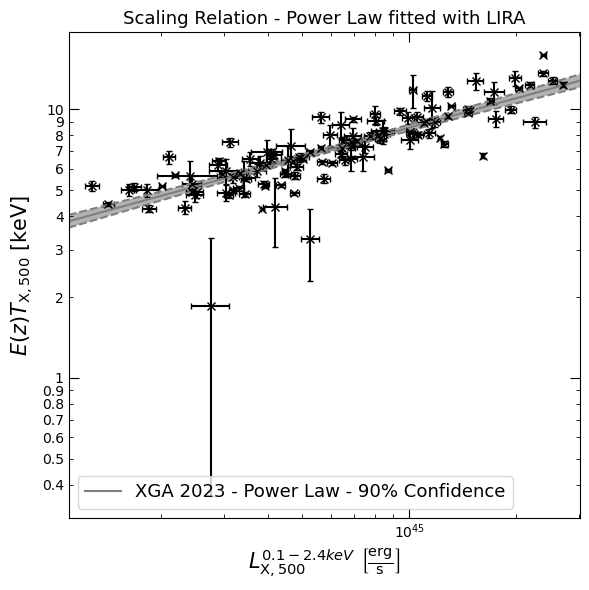

In [5]:
with open('../XMM2023/lovisari_T500vsL_0.12.4_500_xgav0.4.xgarel', 'rb') as reado:
    t_l_rel = pickle.load(reado)
t_l_rel.view(figsize=(6, 6), grid_on=False)

In [6]:
ls = Quantity(chos_samp['L500'].values*1e+44, 'erg/s')
z = chos_samp['redshift'].values
pred_t = t_l_rel.predict(ls, z, cosmo)
pred_t

<Quantity [7.85353596, 6.89863832, 6.5254524 , 6.41740311, 5.95852433,
           5.95145127, 5.81105502, 5.89442149, 5.91987426, 5.81661706,
           5.69885055, 5.64281121, 5.5939655 , 5.46759186, 5.4884695 ,
           5.26858176, 5.16860519, 5.11935533, 5.21383305, 5.06936236,
           5.19270326, 5.08639503, 4.98447715, 4.98192945, 4.87889646,
           4.73011388, 4.68028052, 4.67723629, 4.64148635, 4.54470487,
           4.51370515, 4.4822096 , 4.57183918, 4.41024946, 4.43353755,
           4.56391034, 4.34838838, 4.38886998, 4.27252954, 4.23407984,
           4.29933689, 4.36499868, 4.2599817 , 4.32520805, 4.23488492,
           4.12978001, 4.12041616, 4.12662015, 4.18499737, 4.08827864,
           4.04216092, 4.13739993, 4.16080768, 4.06462207, 4.00081867,
           4.03333281, 4.10382422, 4.06053304, 3.97165039, 4.0713015 ,
           3.96870927, 3.99466325, 3.92608057, 3.84194106, 3.72453964,
           3.61805306, 3.72811599, 3.68239151, 3.73862023, 3.62518397,
      

## Reading the simulation script

In [7]:
with open(COUNTRATE_CONV_SCRIPT, 'r') as c_script:
    script = c_script.read()
    script = script.replace("rm temp_fakeit_spec_", "# rm temp_fakeit_spec_")
    script = script.replace("10000", "{exp}")
print(script)

#  This code is a part of X-ray: Generate and Analyse (XGA), a module designed for the XMM Cluster Survey (XCS).
#  Last modified by David J Turner (david.turner@sussex.ac.uk) 25/08/2020, 11:49. Copyright (c) David J Turner

# This XSPEC script requires parameter's to be filled in by XGA before running.

# The purpose of this script is to calculate count-rate to flux and count-rate to luminosity conversion constants
# These have several uses, upper limit luminosities for instance, as well as making scaling brightness profiles
#  for stacking (see xga.sourcetools.stack).

# This loads the XGA fakeit readout script.
# source

# Allow the user to select the abundance table to use
abund {ab}

# The source object cosmology is used to setup XSPEC cosmo
cosmo {H0} {q0} {lamb0}

# Set up a list of paths to the RMFs we'll be using for fakeit
set rmf_paths {rmf}
# Do the same thing for the corresponding ARFs
set arf_paths {arf}
# Purely for my own convenience, I'm going to add corresponding list

In [8]:
# Setting up paths to files required for simulating XRISM spectrum - these will be filled in with ObsID
#  and instrument when required
res_arf_path = os.getcwd() + "/responses/rsl_extbeta_GVclosed.arf"
res_rmf_path = os.getcwd() + "/responses/rsl_Hp_5eV.rmf"

ext_arf_path = os.getcwd() + "/responses/xtd_extflatcircle.arf"
ext_rmf_path = os.getcwd() + "/responses/xtd_standard.rmf"

Running Simulations:   0%|          | 0/82 [00:00<?, ?it/s]

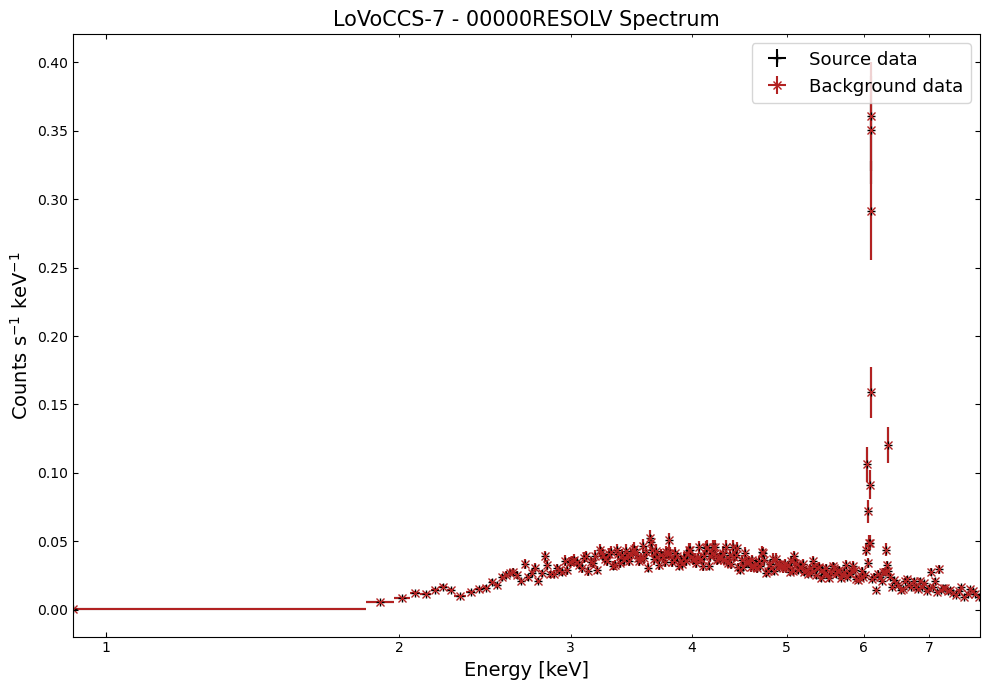

Running Simulations:   1%|          | 1/82 [01:02<1:24:32, 62.62s/it]

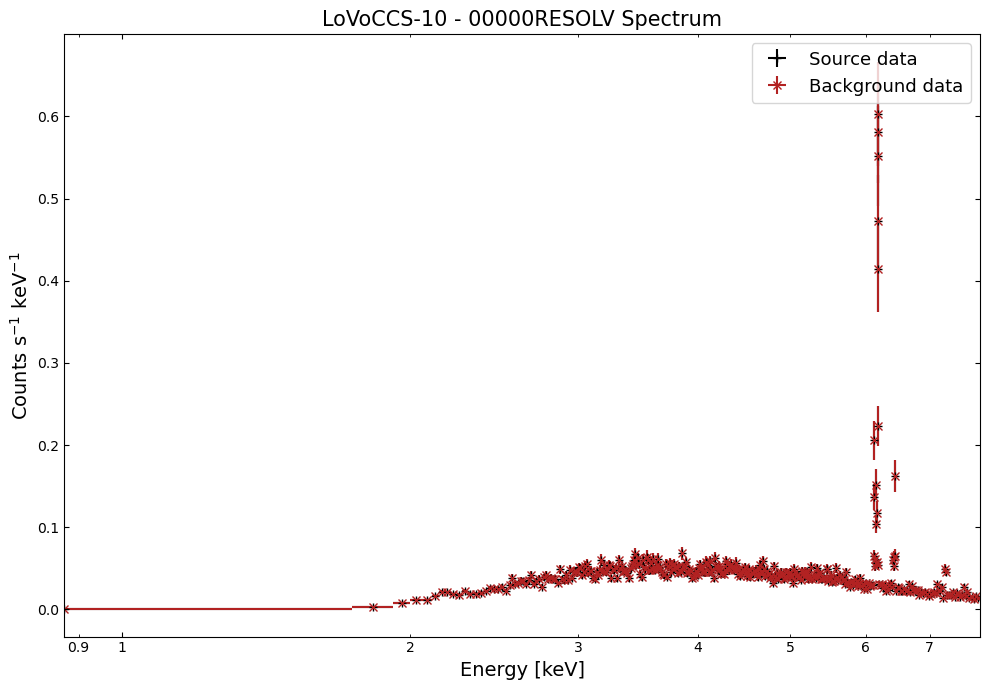

Running Simulations:   2%|▏         | 2/82 [02:28<1:42:00, 76.50s/it]

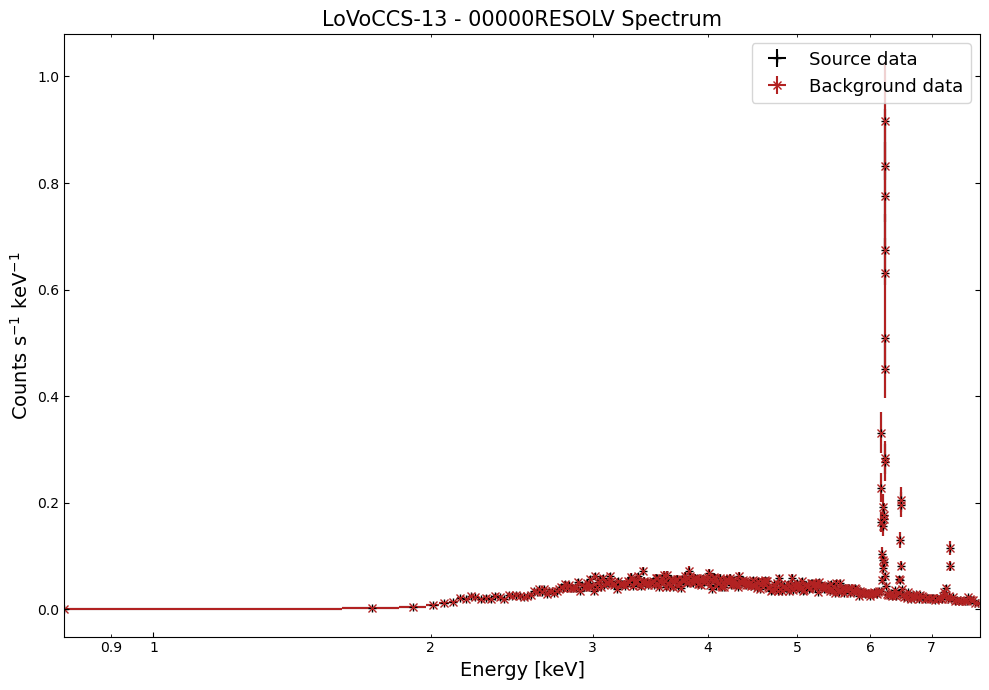

Running Simulations:   4%|▎         | 3/82 [04:13<1:57:25, 89.19s/it]

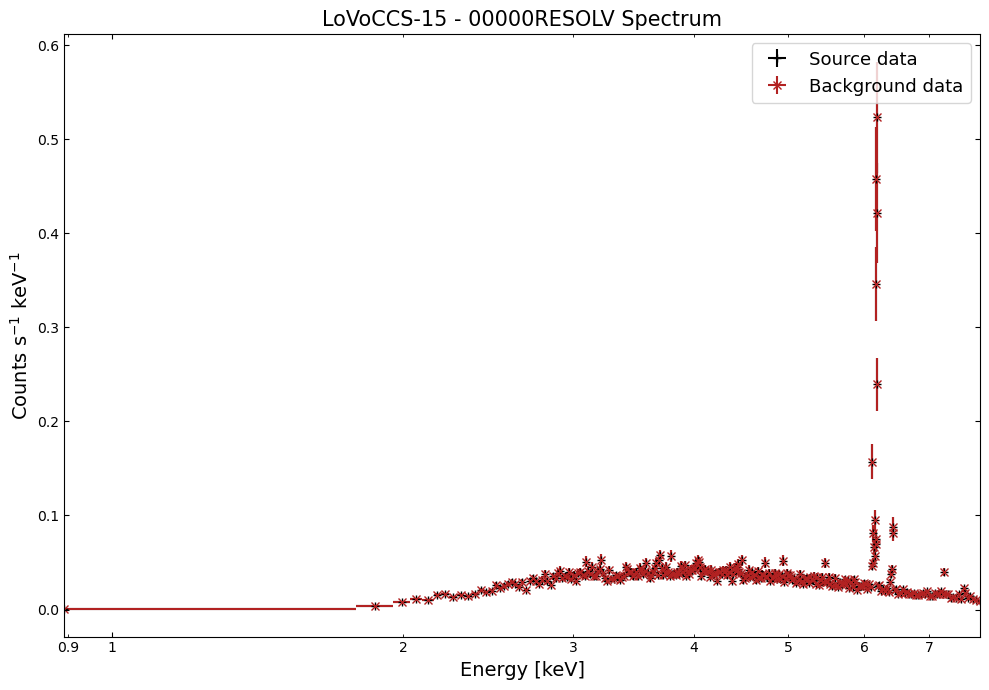

Running Simulations:   5%|▍         | 4/82 [05:28<1:48:50, 83.72s/it]

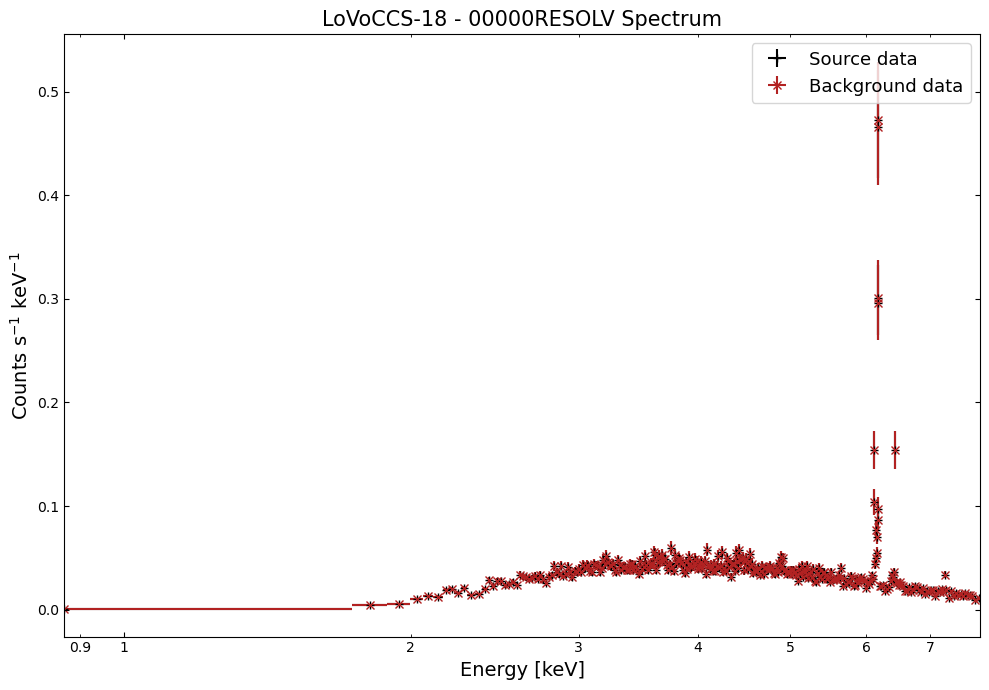

Running Simulations:   6%|▌         | 5/82 [06:34<1:39:14, 77.33s/it]

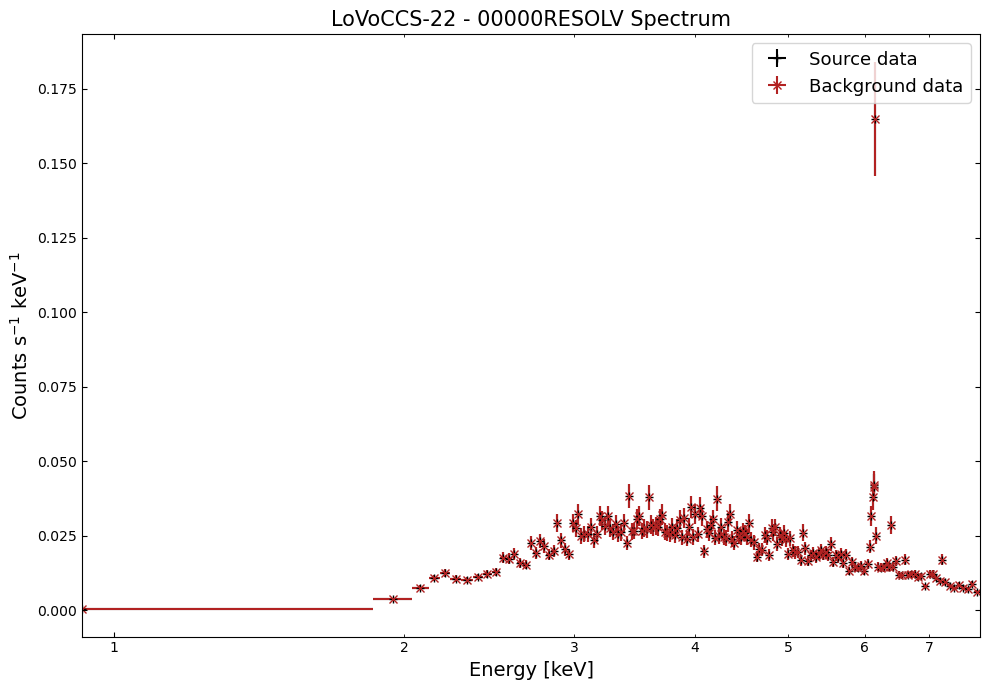

Running Simulations:   7%|▋         | 6/82 [07:25<1:26:41, 68.45s/it]

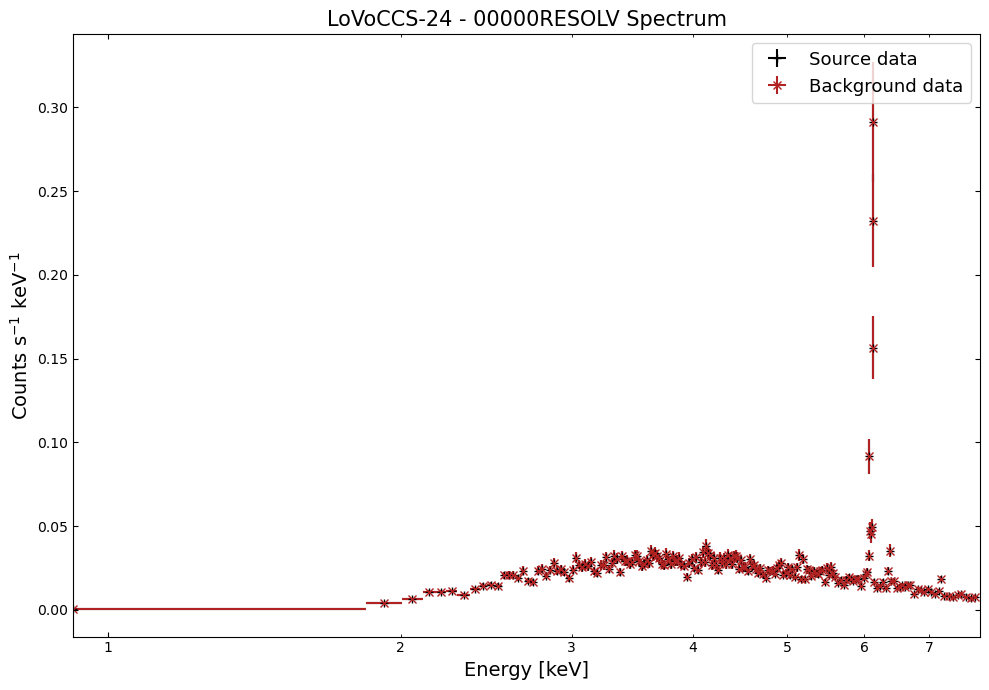

Running Simulations:   9%|▊         | 7/82 [08:20<1:19:49, 63.85s/it]

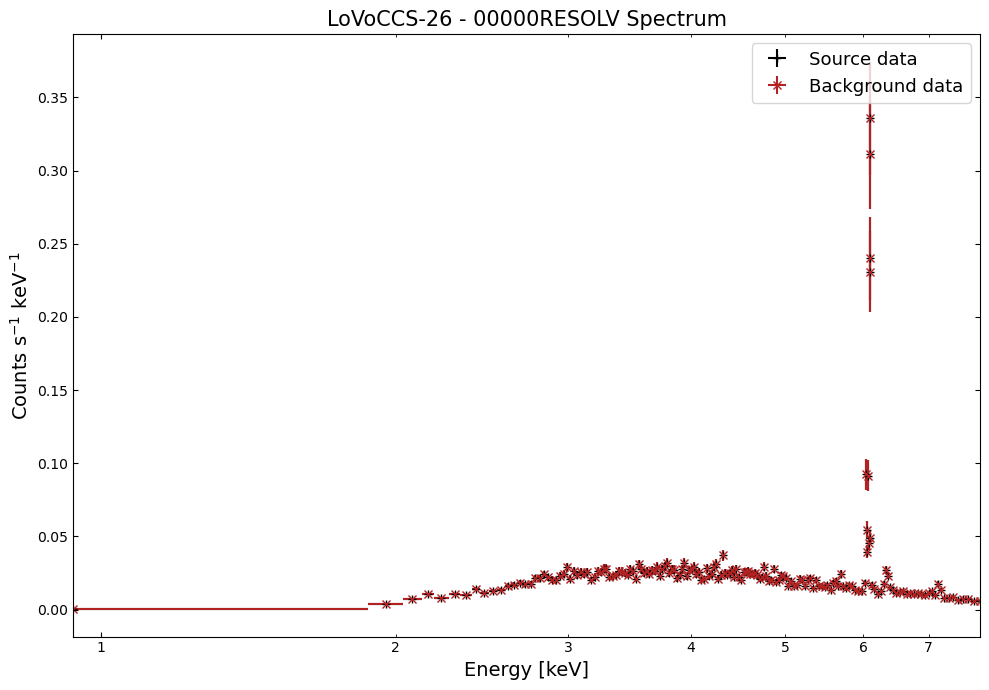

Running Simulations:  10%|▉         | 8/82 [09:02<1:10:20, 57.03s/it]

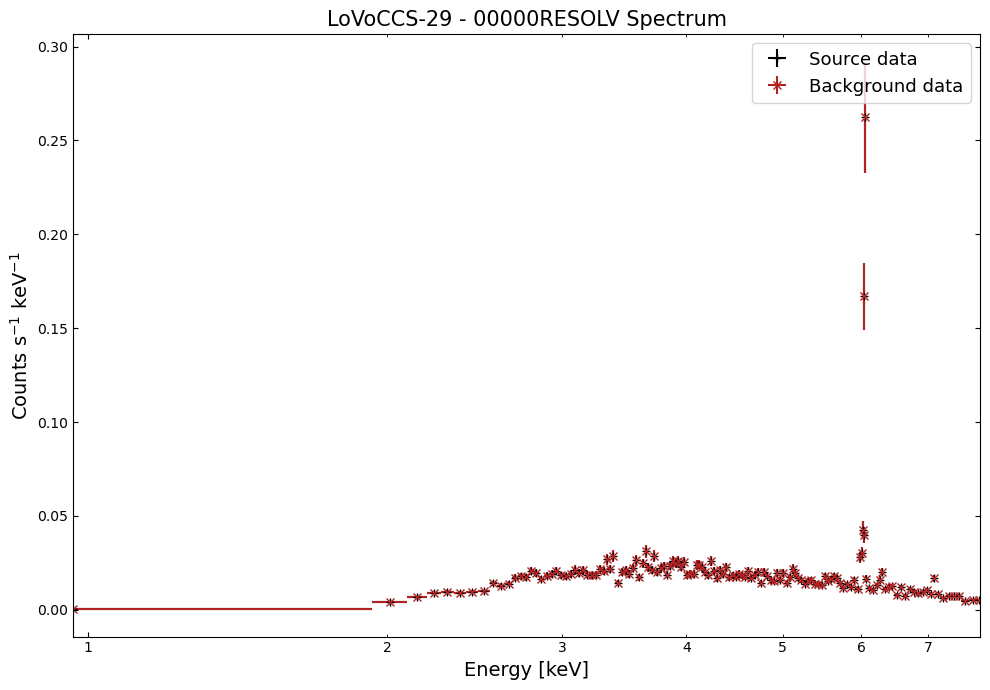

Running Simulations:  11%|█         | 9/82 [09:50<1:05:54, 54.18s/it]

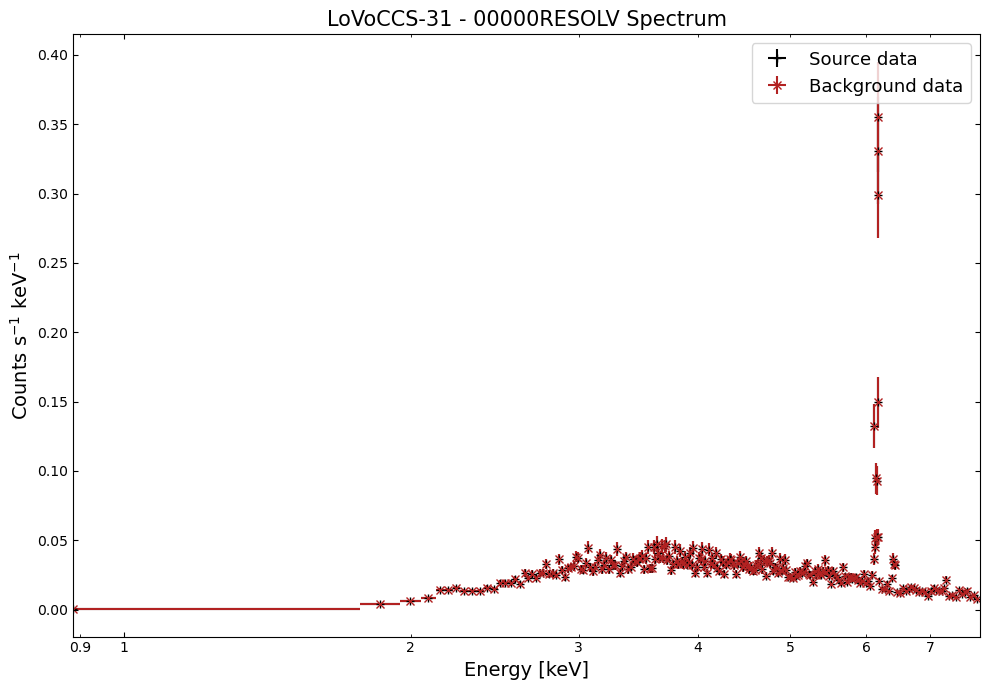

Running Simulations:  12%|█▏        | 10/82 [10:35<1:01:45, 51.47s/it]

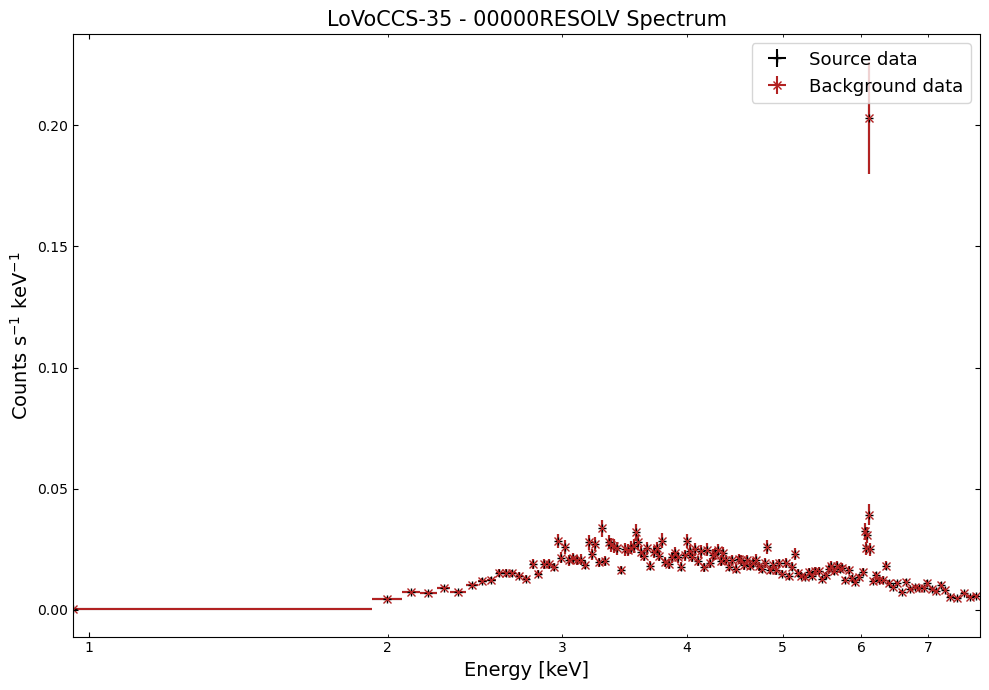

Running Simulations:  13%|█▎        | 11/82 [11:19<58:03, 49.07s/it]  

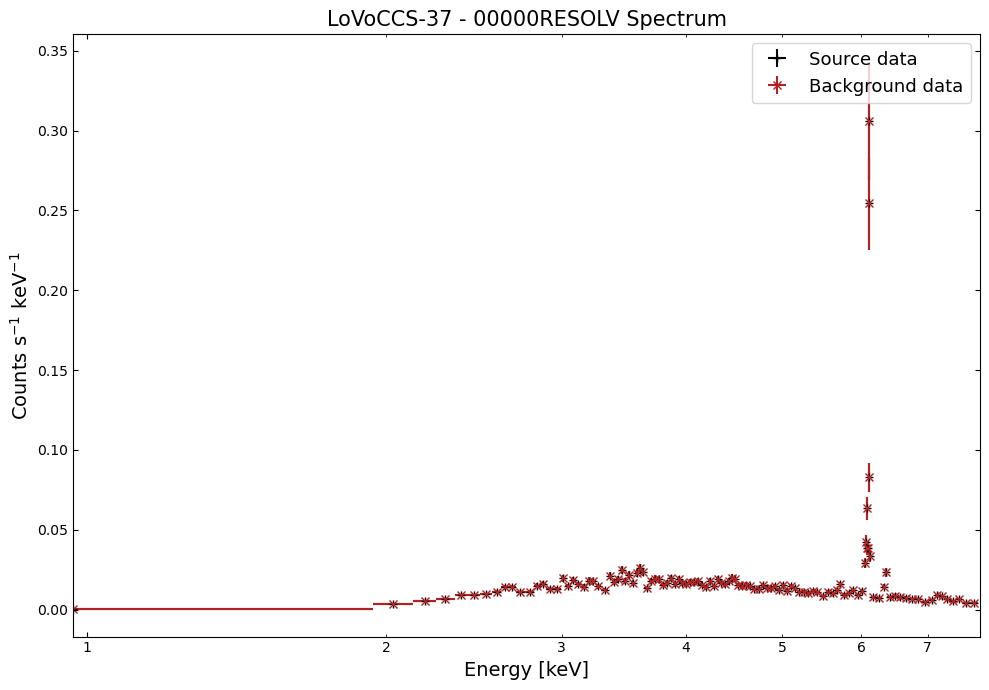

Running Simulations:  15%|█▍        | 12/82 [12:07<56:56, 48.81s/it]

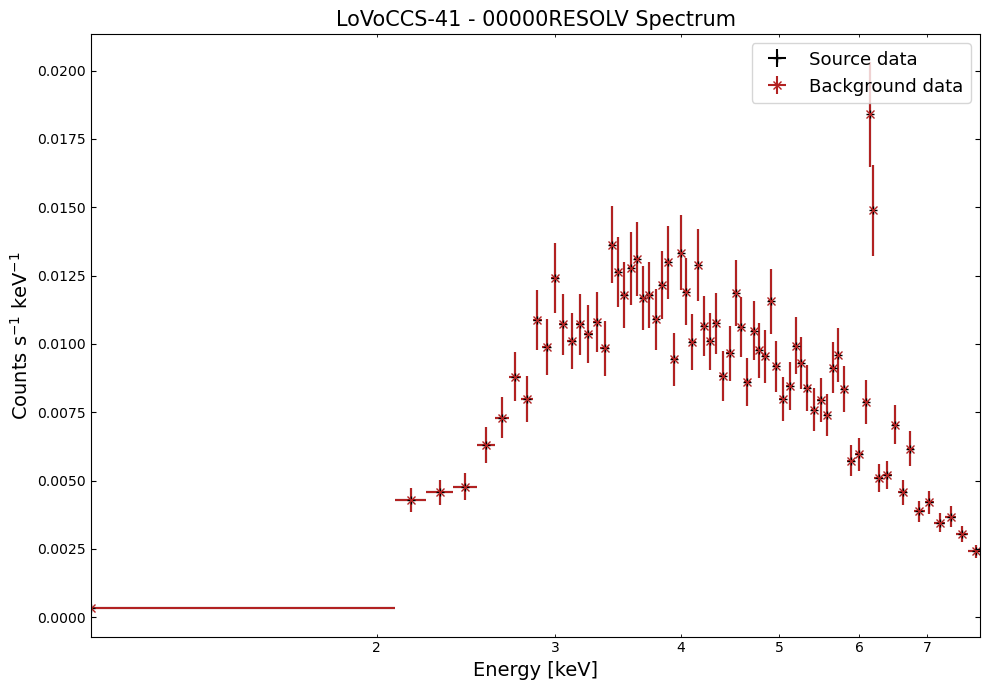

Running Simulations:  16%|█▌        | 13/82 [12:51<54:29, 47.38s/it]

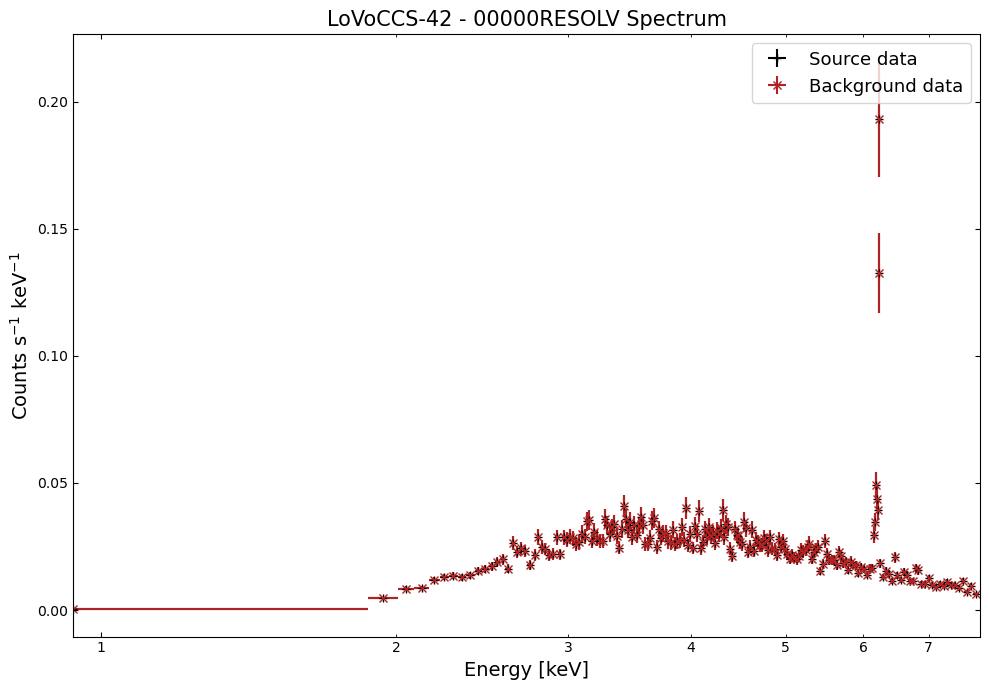

Running Simulations:  17%|█▋        | 14/82 [13:42<54:52, 48.42s/it]

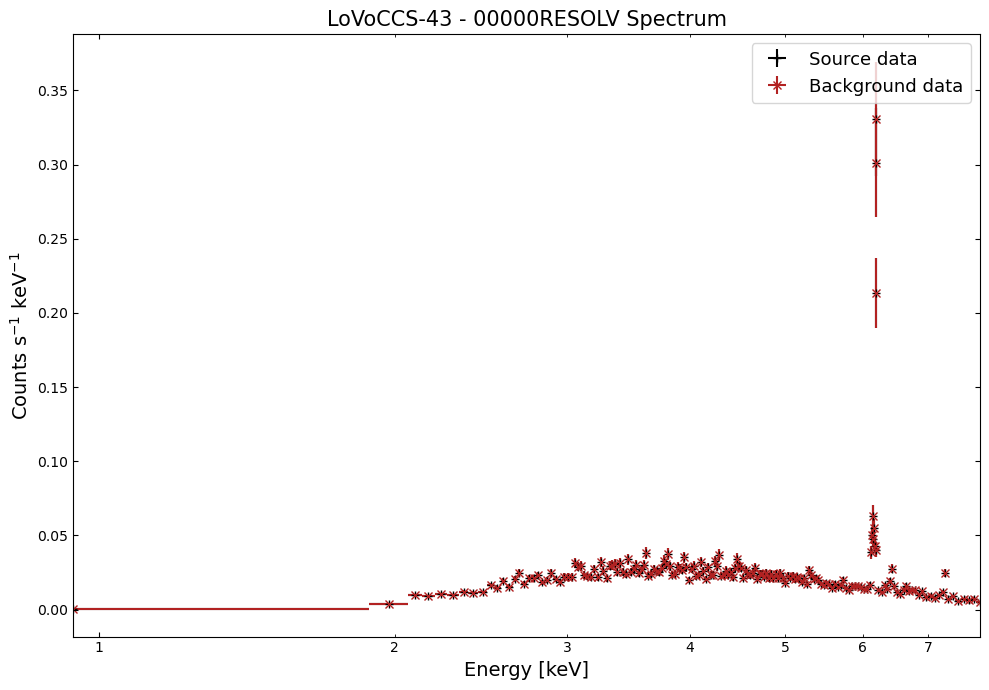

Running Simulations:  18%|█▊        | 15/82 [14:27<52:51, 47.34s/it]

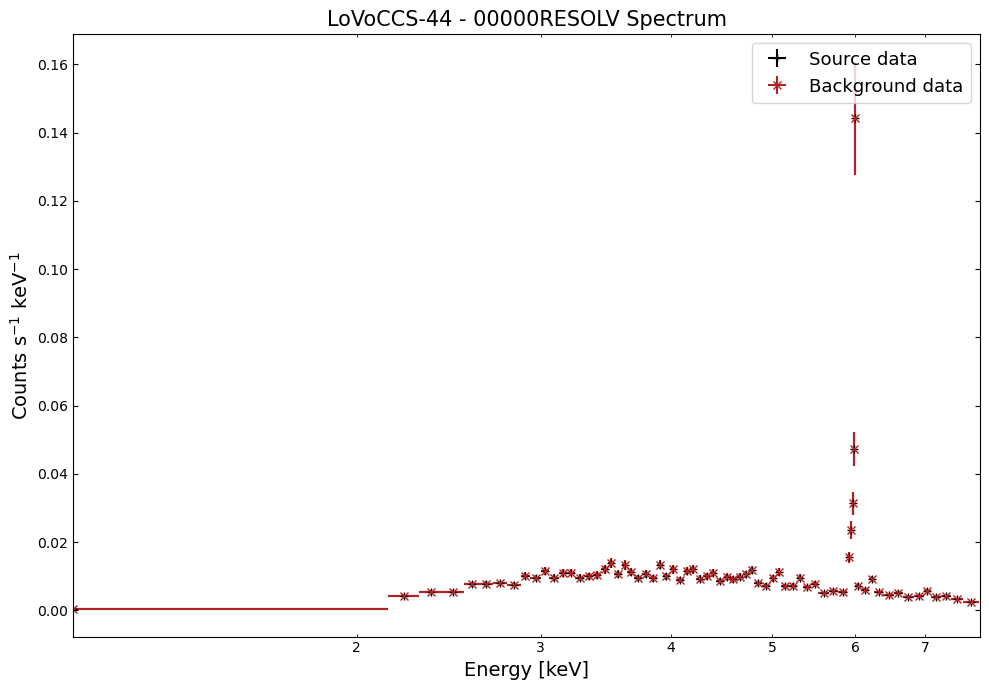

Running Simulations:  20%|█▉        | 16/82 [15:08<49:58, 45.44s/it]

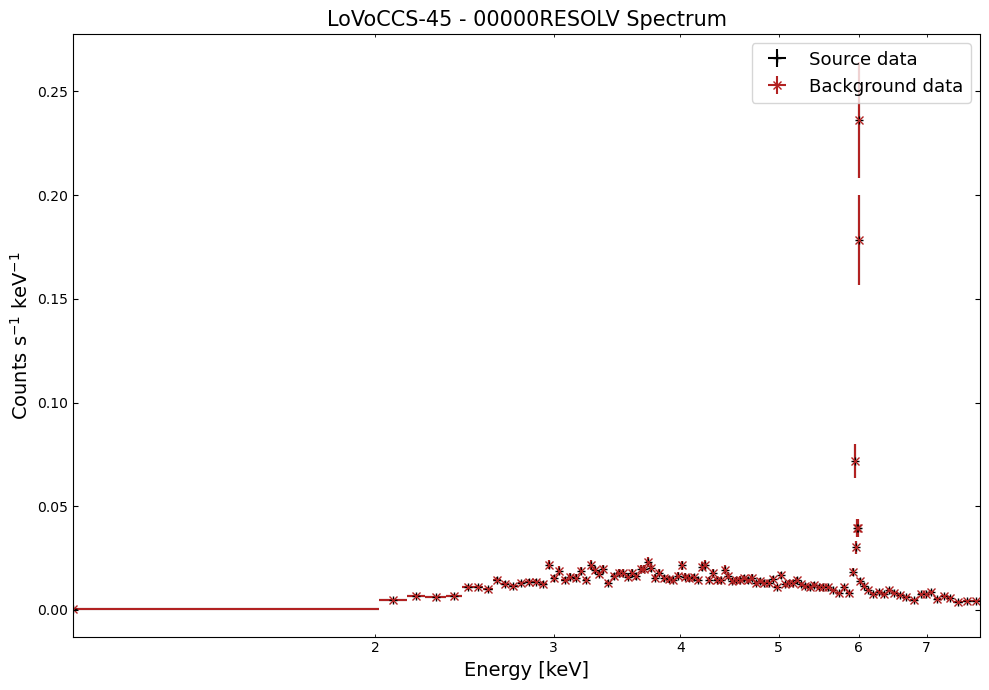

Running Simulations:  21%|██        | 17/82 [15:50<48:04, 44.38s/it]

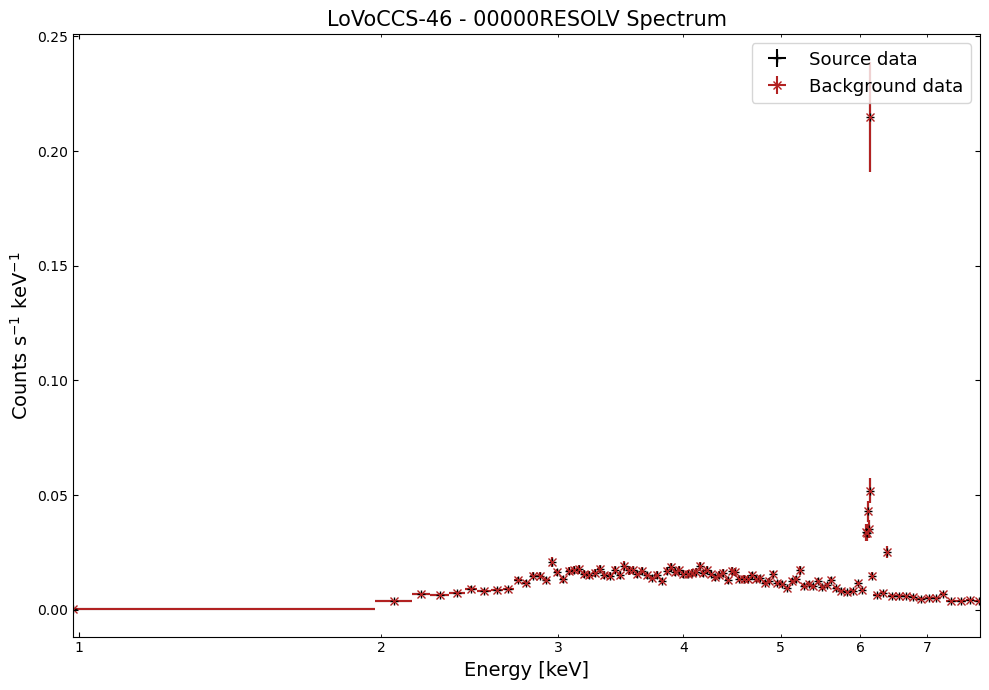

Running Simulations:  23%|██▎       | 19/82 [17:11<44:01, 41.93s/it]

LoVoCCS-48


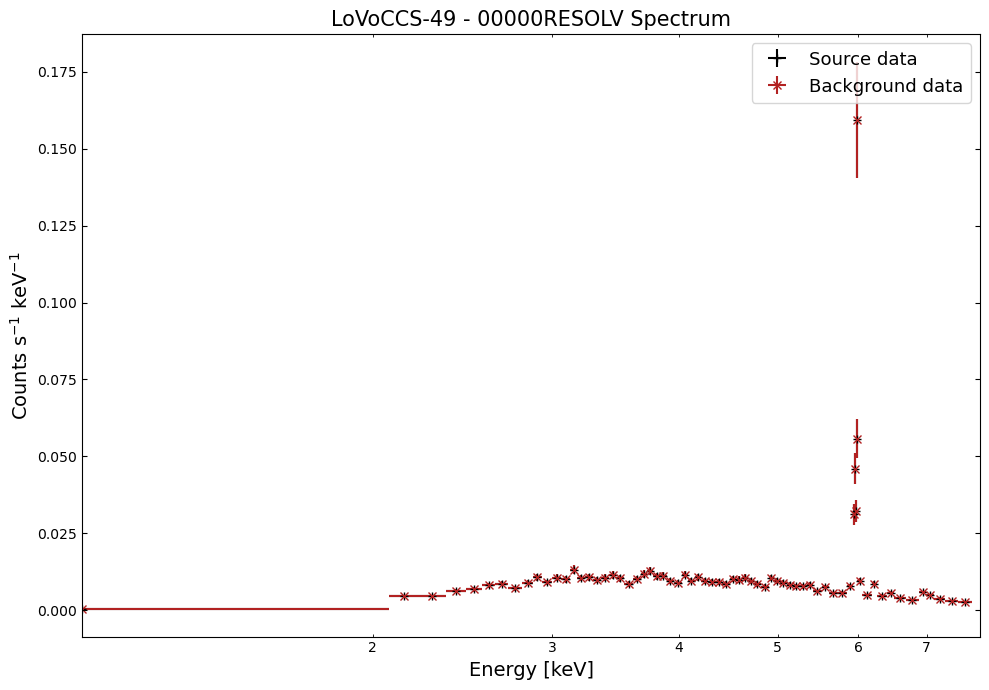

Running Simulations:  24%|██▍       | 20/82 [18:04<46:55, 45.41s/it]

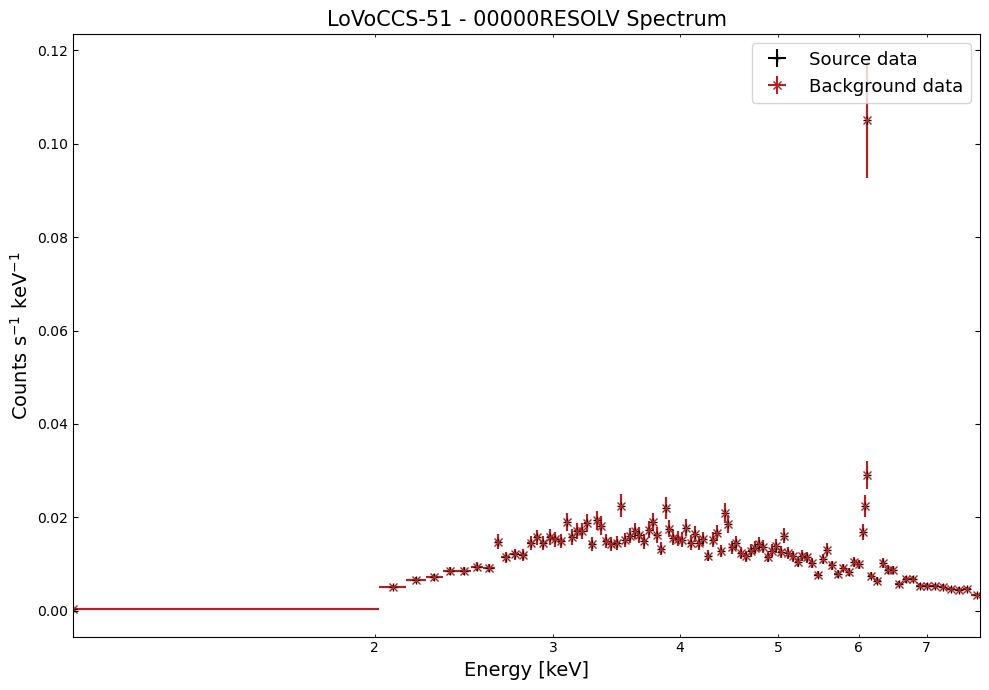

Running Simulations:  26%|██▌       | 21/82 [18:51<46:35, 45.83s/it]

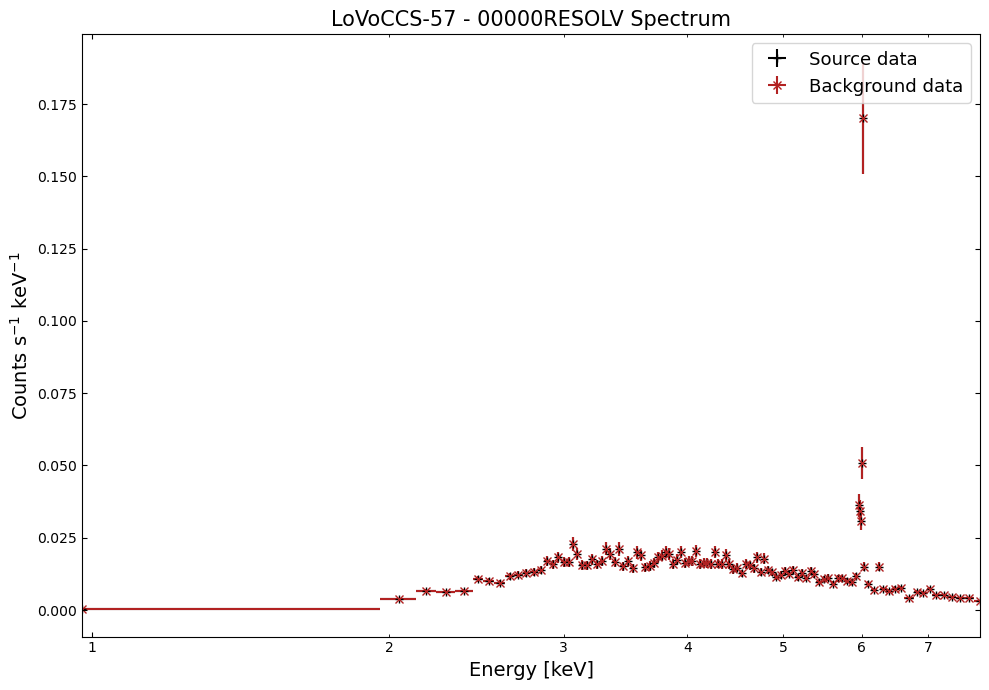

Running Simulations:  27%|██▋       | 22/82 [19:37<45:51, 45.86s/it]

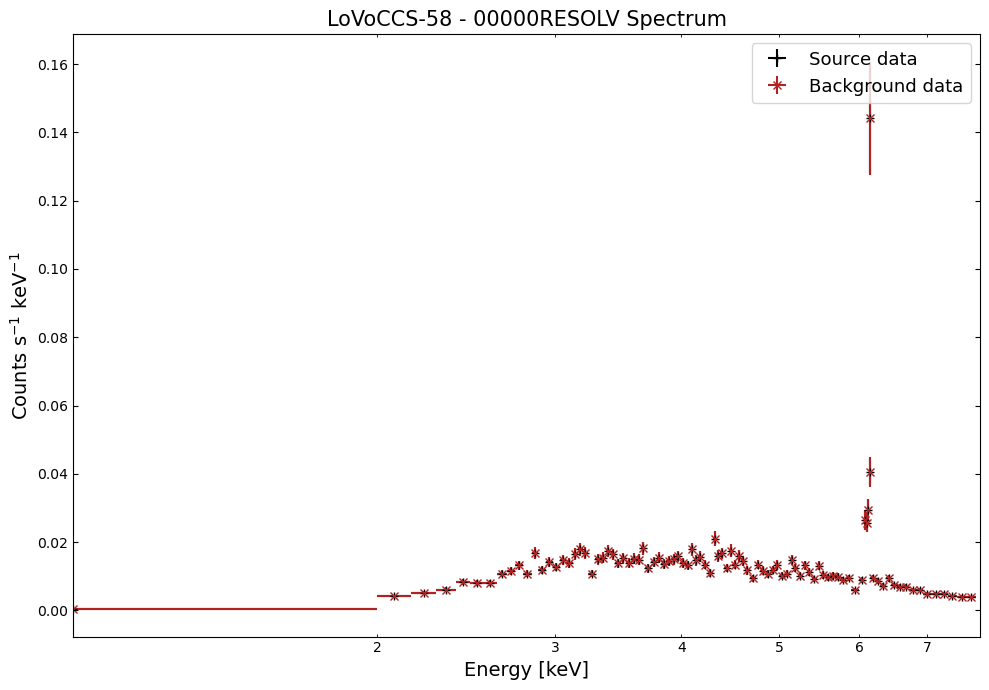

Running Simulations:  28%|██▊       | 23/82 [20:38<49:31, 50.36s/it]

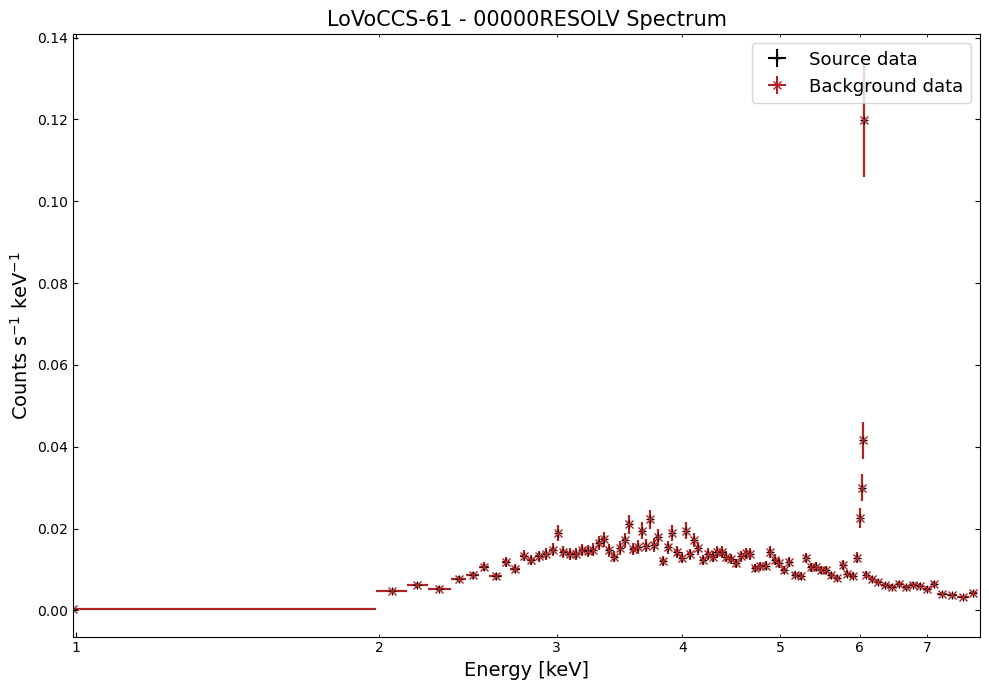

Running Simulations:  29%|██▉       | 24/82 [21:34<50:17, 52.02s/it]

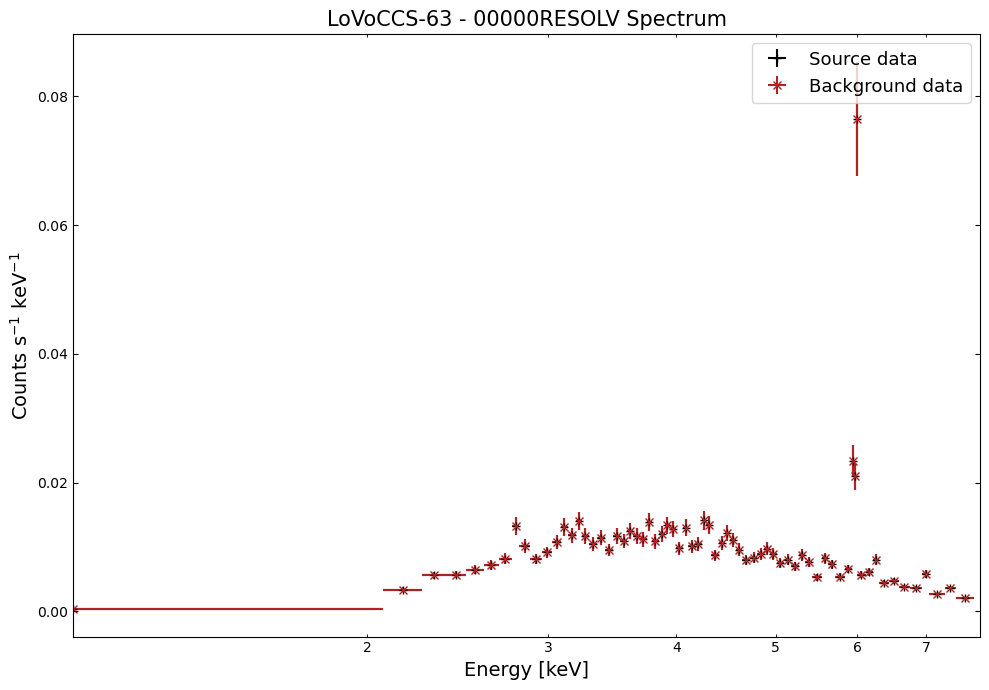

Running Simulations:  30%|███       | 25/82 [22:33<51:26, 54.15s/it]

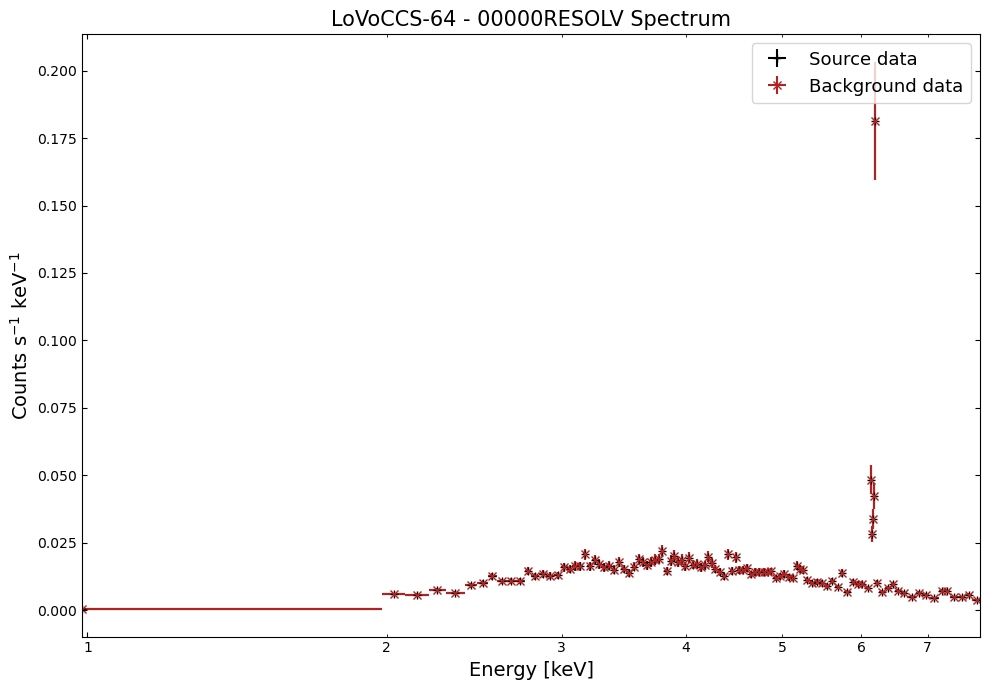

Running Simulations:  32%|███▏      | 26/82 [23:25<49:51, 53.42s/it]

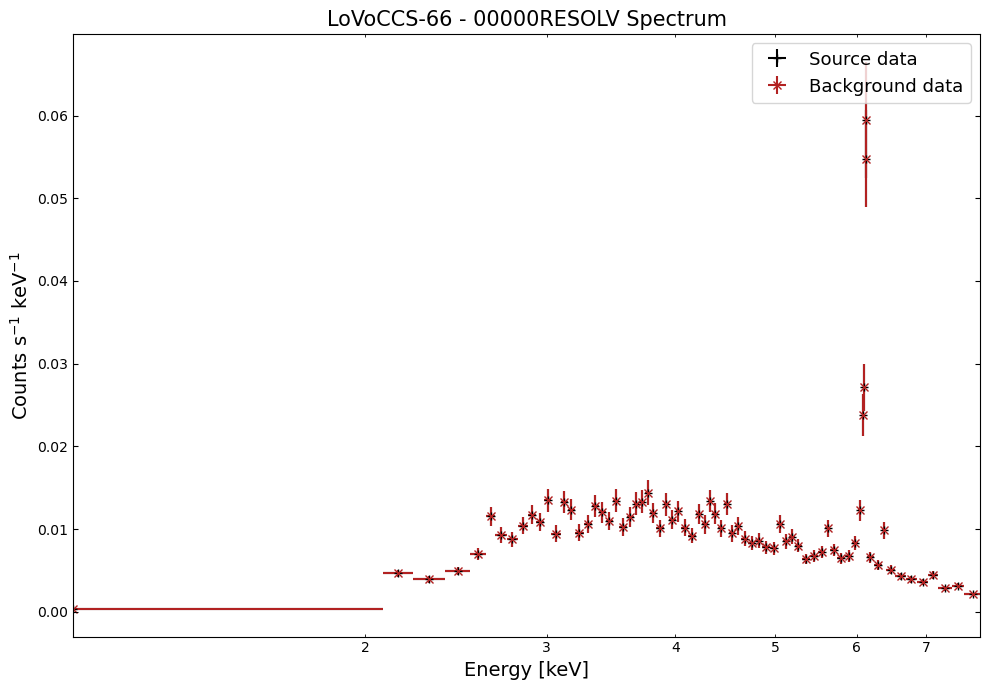

Running Simulations:  33%|███▎      | 27/82 [24:19<49:06, 53.57s/it]

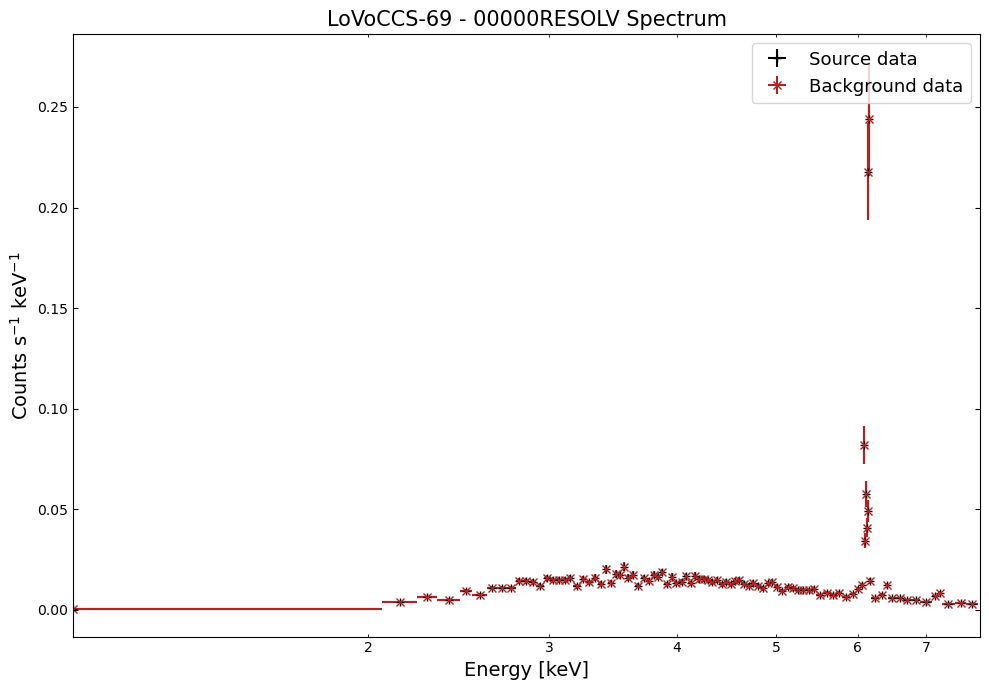

Running Simulations:  34%|███▍      | 28/82 [25:02<45:25, 50.47s/it]

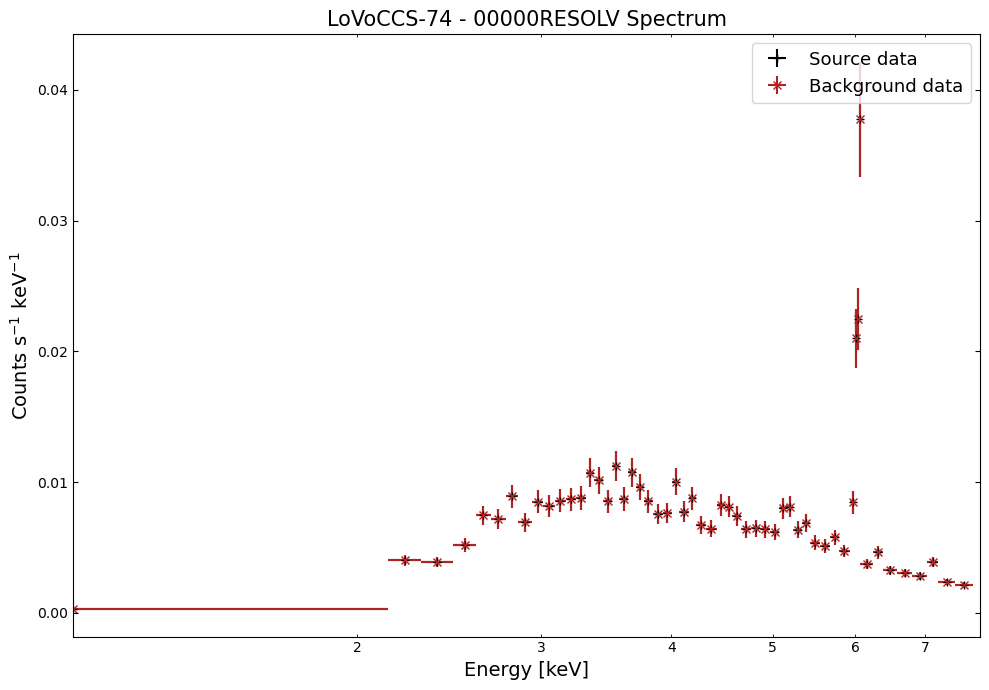

Running Simulations:  35%|███▌      | 29/82 [25:46<42:59, 48.67s/it]

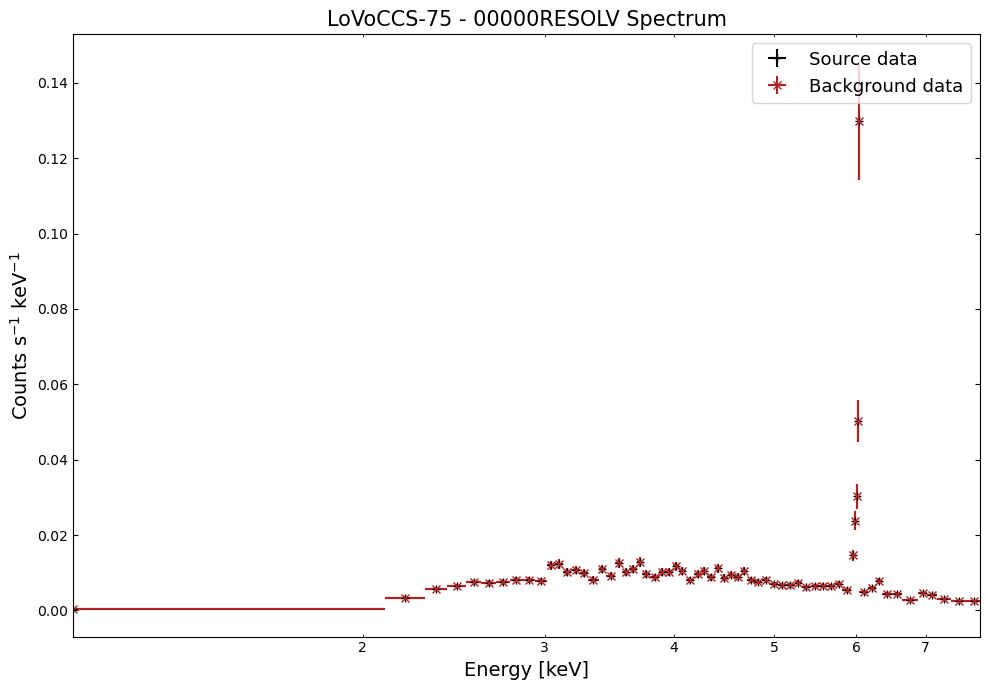

Running Simulations:  37%|███▋      | 30/82 [26:30<40:53, 47.18s/it]

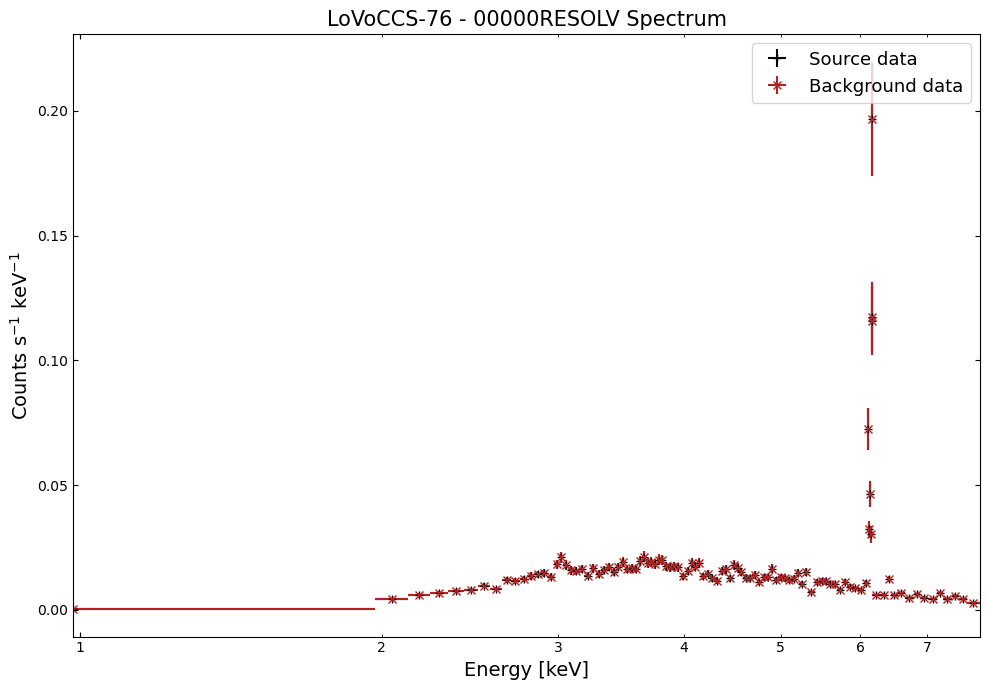

Running Simulations:  38%|███▊      | 31/82 [27:24<41:56, 49.34s/it]

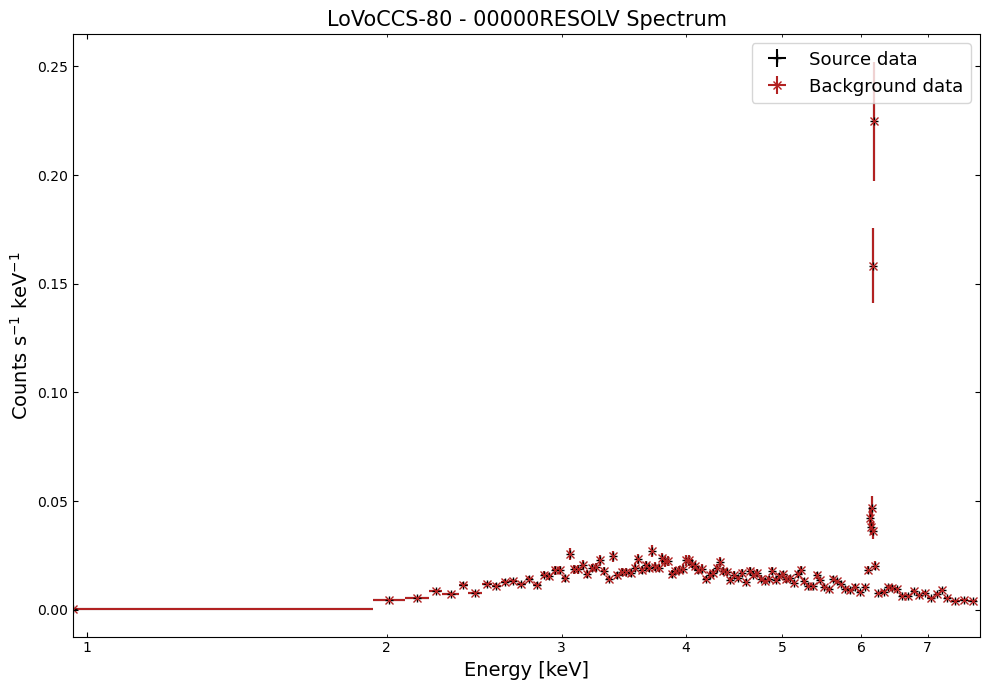

Running Simulations:  39%|███▉      | 32/82 [28:20<42:38, 51.17s/it]

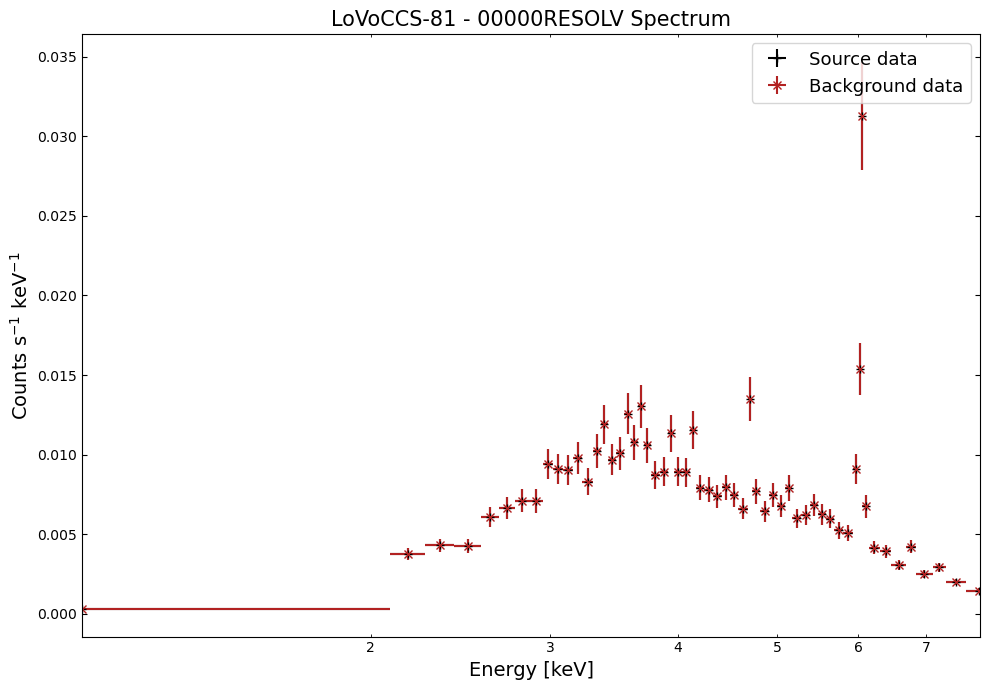

Running Simulations:  40%|████      | 33/82 [29:33<47:10, 57.76s/it]

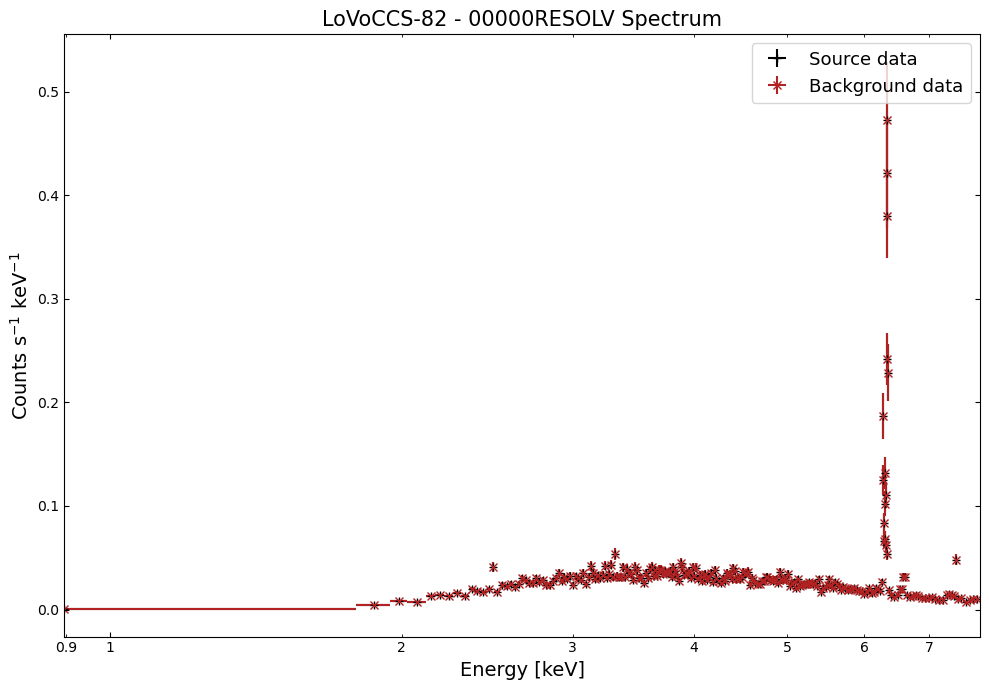

Running Simulations:  41%|████▏     | 34/82 [30:50<50:49, 63.53s/it]

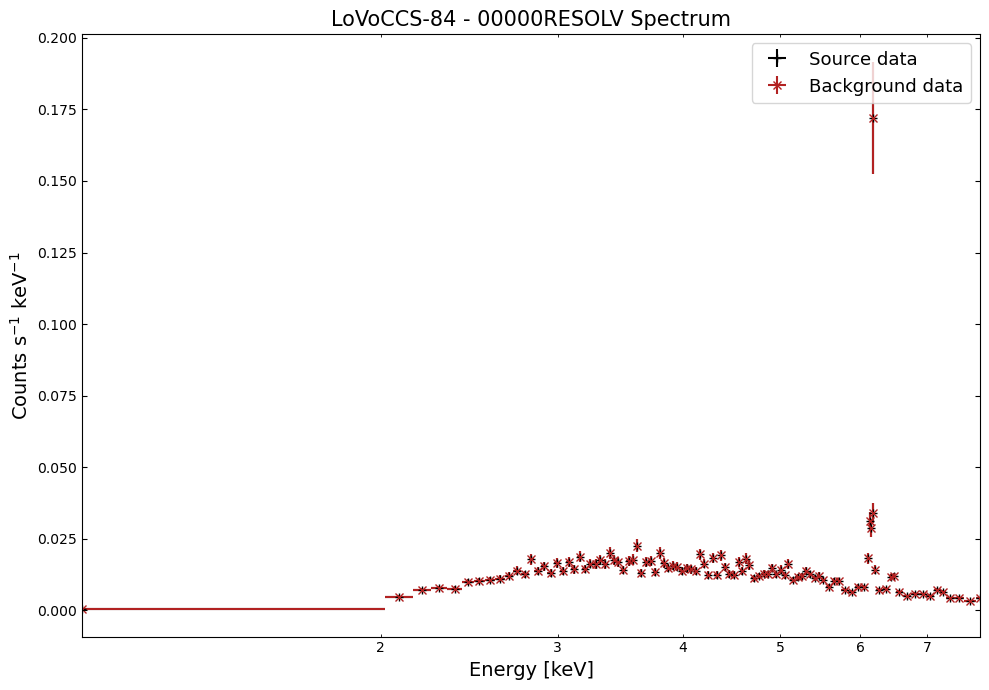

Running Simulations:  43%|████▎     | 35/82 [31:42<47:08, 60.19s/it]

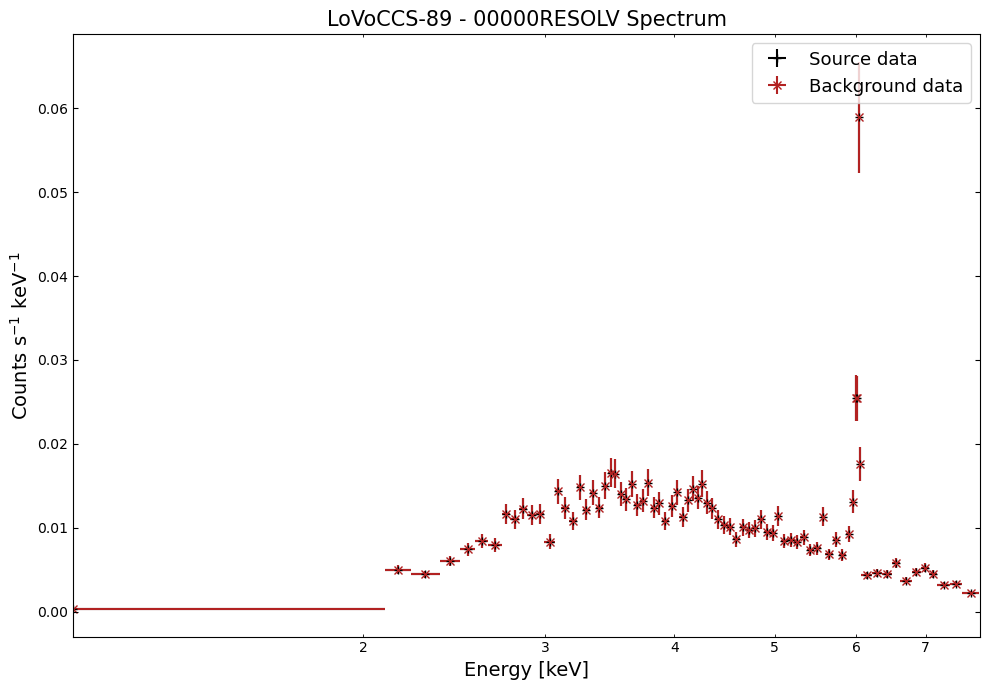

Running Simulations:  44%|████▍     | 36/82 [32:42<45:57, 59.94s/it]

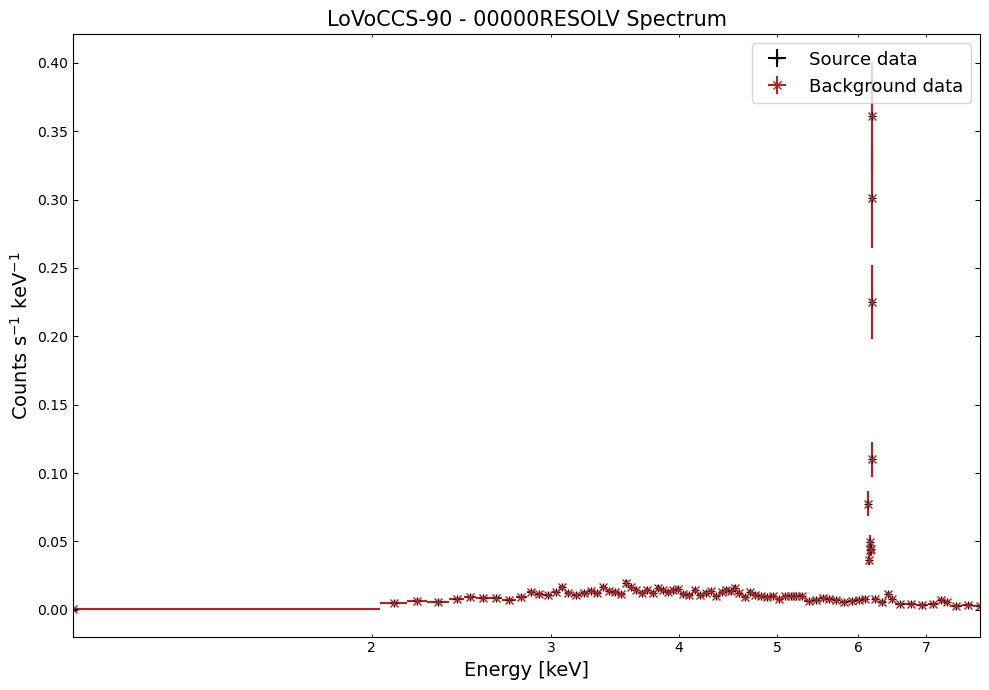

Running Simulations:  45%|████▌     | 37/82 [33:25<41:12, 54.94s/it]

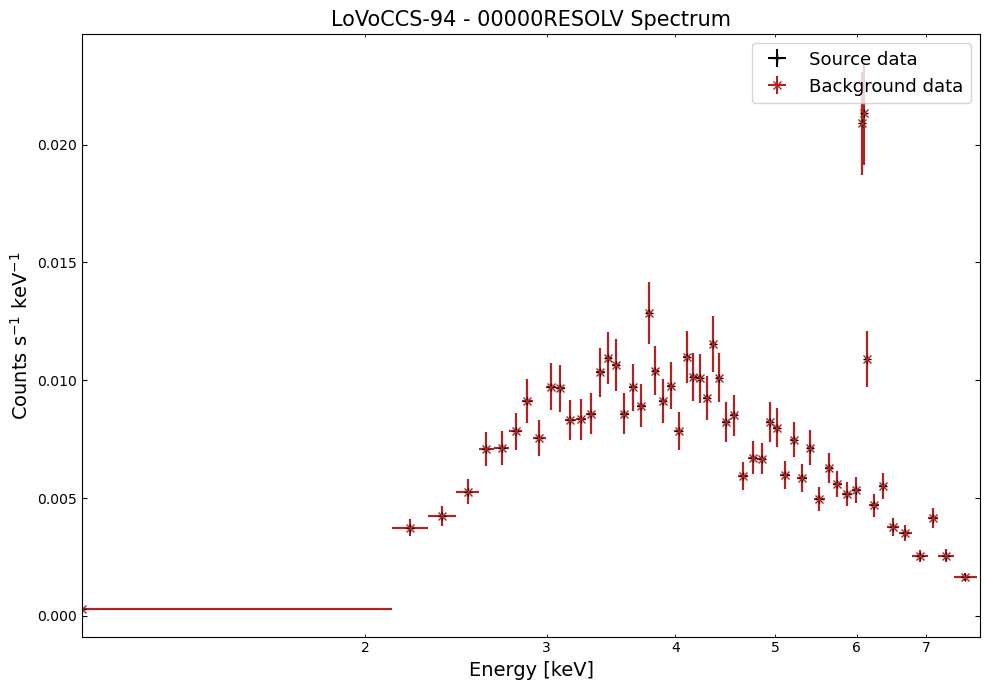

Running Simulations:  46%|████▋     | 38/82 [34:12<38:32, 52.55s/it]

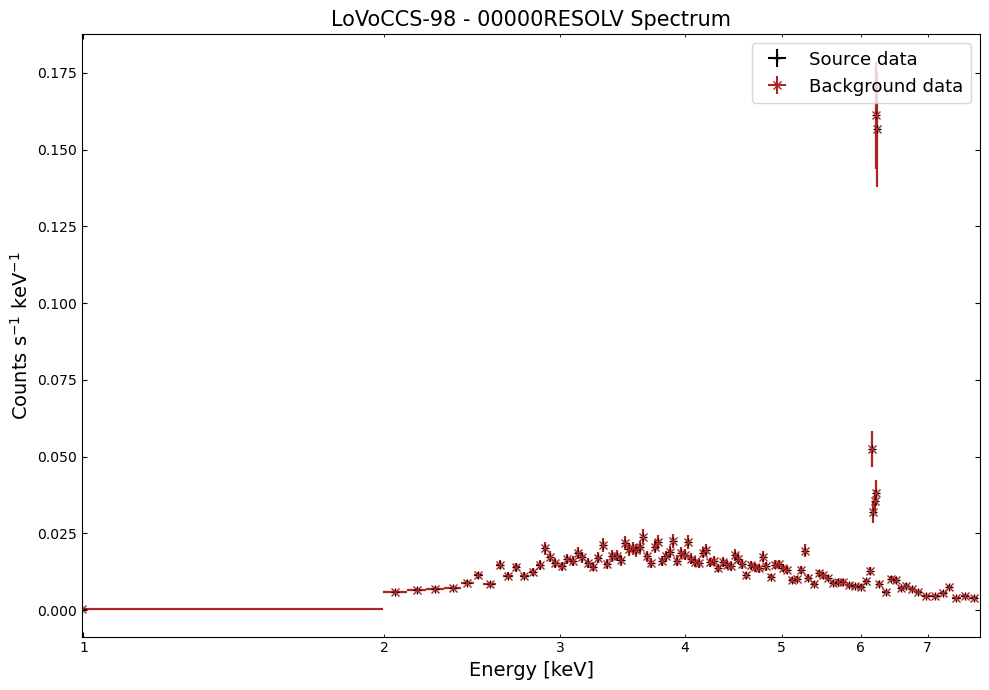

Running Simulations:  48%|████▊     | 39/82 [35:02<37:08, 51.82s/it]

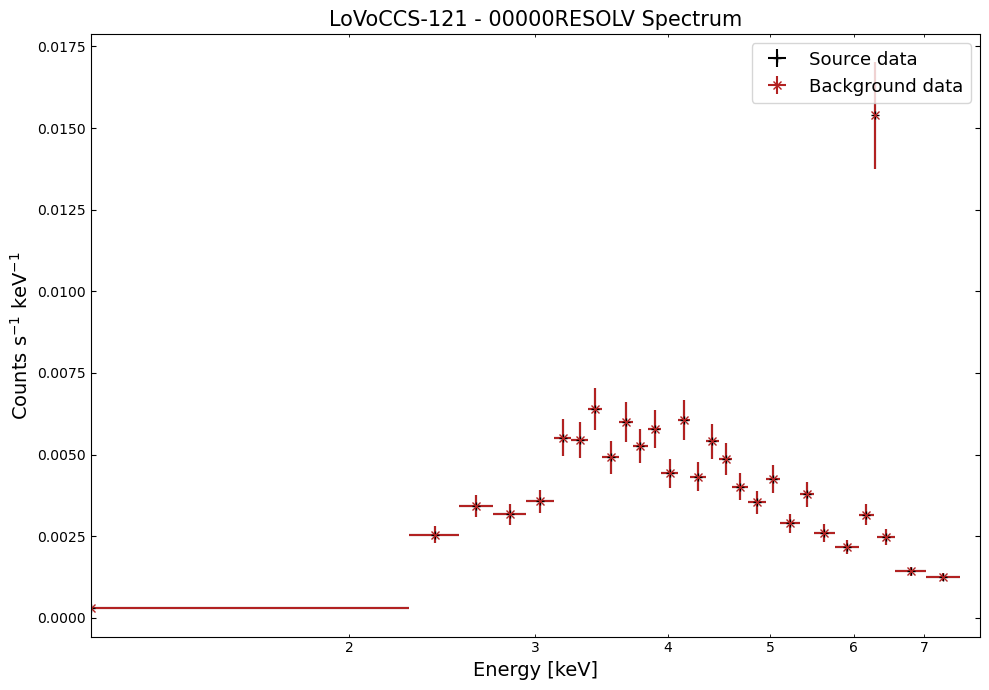

Running Simulations:  49%|████▉     | 40/82 [35:44<34:12, 48.87s/it]

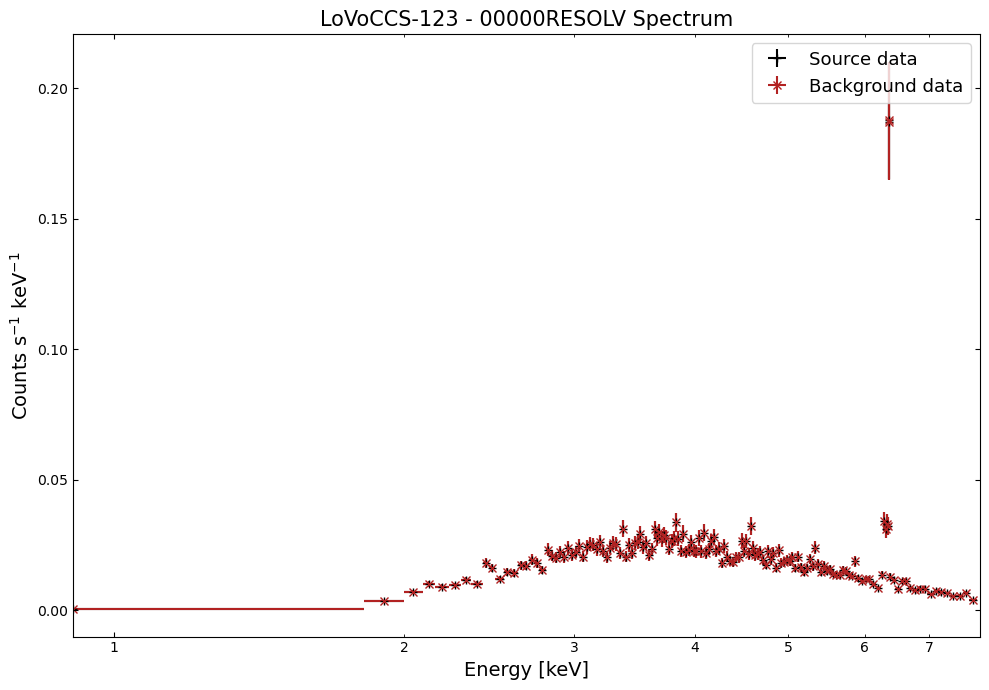

Running Simulations:  50%|█████     | 41/82 [36:26<31:54, 46.70s/it]

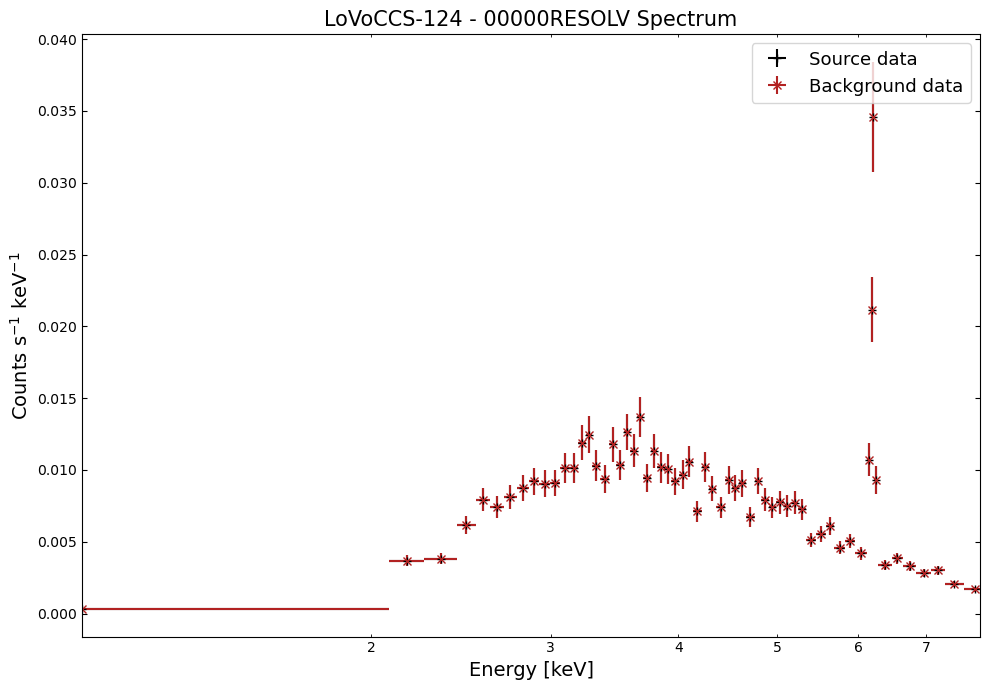

Running Simulations:  51%|█████     | 42/82 [37:14<31:27, 47.19s/it]

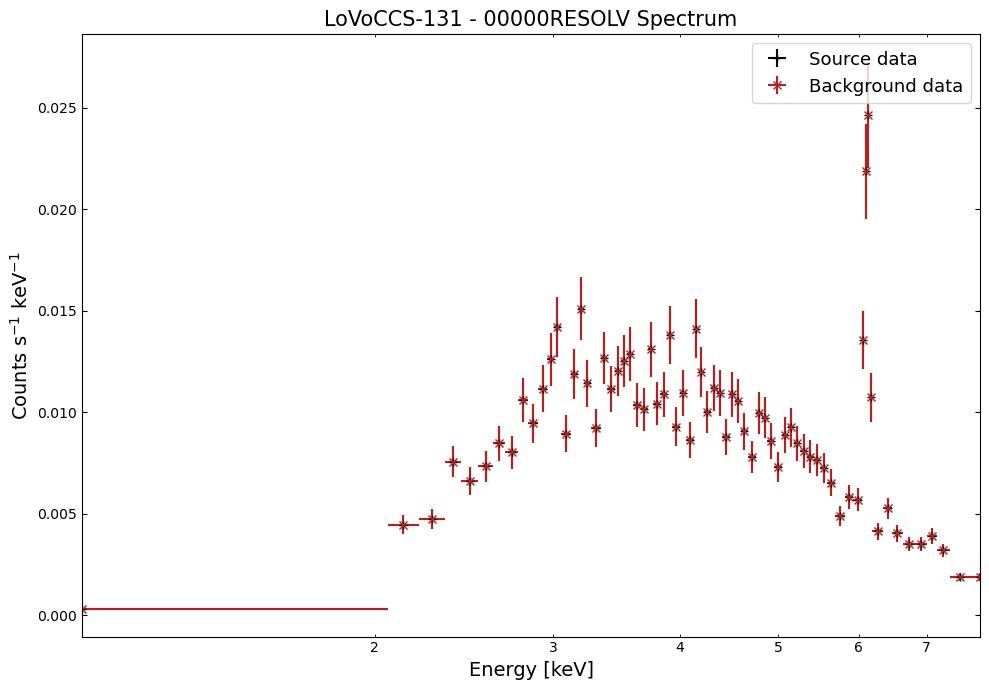

Running Simulations:  52%|█████▏    | 43/82 [38:00<30:23, 46.76s/it]

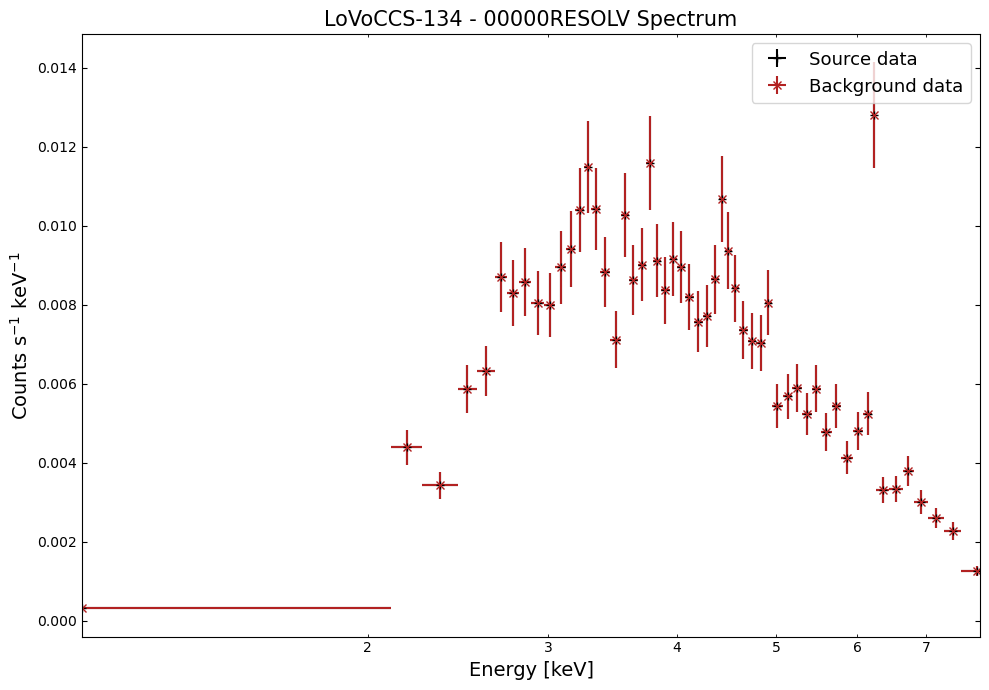

Running Simulations:  54%|█████▎    | 44/82 [38:47<29:39, 46.83s/it]

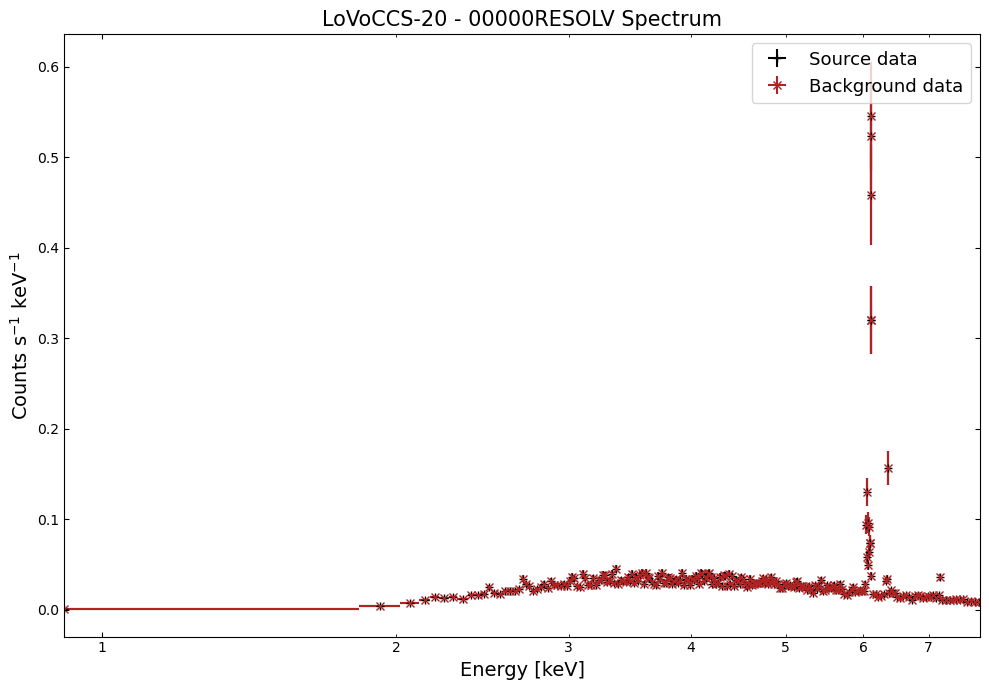

Running Simulations:  55%|█████▍    | 45/82 [40:15<33:06, 53.69s/it]


IndexError: list index out of range

In [9]:
arfs_str = "{" + res_arf_path + "}"
rmfs_str = "{" + res_rmf_path + "}"

obs_str = "{00000}"
inst_str = "{RESOLVE}"

lo_lims = "{0.5 0.1 0.01}"
hi_lims = "{2.0 2.4 100.0}"

og_dir = os.getcwd()
resolv_sps = {}
with tqdm(total=len(chos_samp), desc="Running Simulations") as onwards:
    for row_ind, row in chos_samp.iterrows():
        if not os.path.exists("sim_outputs/{}".format(row['LoVoCCS_name'])):
            os.makedirs("sim_outputs/{}".format(row['LoVoCCS_name']))
        
        rel_xmm_res = res[res['LoVoCCS_name'] == row['LoVoCCS_name']]
        if len(rel_xmm_res) == 1:
            rel_xmm_res = rel_xmm_res.iloc[0]
        else:
            continue
            
        if np.isnan(rel_xmm_res['r500']):
            continue
            norm = 0.1
            met = 0.3
        else:
            ang_r500 = rad_to_ang(Quantity(rel_xmm_res['r500'], 'kpc'), row['redshift'], cosmo)
            cur_pth = "../../../X-LoVoCCS-Analyses/notebooks/xga_output/XSPEC/{n}/".format(n=row['LoVoCCS_name'])
            cur_f = [f for f in os.listdir(cur_pth) if '_ri0.0_' in f and "ro{}".format(ang_r500.value) in f and 
                     'results' in f and 'tbabs*apec' in f][0]
            cur_sp_res = pd.read_csv(cur_pth + cur_f)
            
            norm = cur_sp_res['norm|6'].values[0]
            met = rel_xmm_res['Zmet500']
                    
        os.chdir("sim_outputs/{}".format(row['LoVoCCS_name']))
        
        outfile = "sim.csv".format(row['LoVoCCS_name'])
        scfile = "sim.xcm".format(row['LoVoCCS_name'])

        nh = nh_lookup(Quantity([row['ra'], row['dec']], 'deg'))[0].value
        temp = pred_t[row_ind].value
        par_vals = "{" + " ".join([str(nh), str(temp), str(met), str(row['redshift']), str(norm)]) + "}"
        
        exposure = "150000"
        
        cur_script = script.format(ab='angr', H0=cosmo.H0.value, q0=0., lamb0=cosmo.Ode0, rmf=rmfs_str, 
                                   arf=arfs_str, obs=obs_str, inst=inst_str, m="tbabs*apec", 
                                   pn="{nH kT Abundanc Redshift norm}", pv=par_vals, lll=lo_lims, 
                                   lul=hi_lims, redshift=str(row['redshift']), of=outfile, 
                                   rid="resolve{}".format(row['LoVoCCSID']), exp=exposure)
        
        with open(scfile, 'w') as scripto:
            scripto.write(cur_script)
                
        out, err = Popen("xspec - " + scfile, shell=True, stdout=PIPE, stderr=PIPE).communicate()
        
        sp_file = og_dir + "/sim_outputs/{n}/temp_fakeit_spec_resolve{i}.fits".format(n=row['LoVoCCS_name'], 
                                                                                      i=row['LoVoCCSID'])
        min_cnt = 50
        grp_sp_file = sp_file.replace("_spec_", "_grpspec_")
        grp_cmd = 'ftgrouppha infile="{infi}" outfile="{of}" grouptype="min" '\
                'groupscale="{gs}"'.format(infi=sp_file, of=grp_sp_file, gs=min_cnt)
        grp_cmd = 'export HEADASNOQUERY=; export HEADASPROMPT=/dev/null;' + grp_cmd

        out, err = Popen(grp_cmd, shell=True, stdout=PIPE, stderr=PIPE).communicate()
        
        try:
            sp = Spectrum(grp_sp_file, res_rmf_path, res_arf_path, grp_sp_file, Quantity([0, 0], 'deg'), 
                          Quantity(0, 'arcmin'), Quantity(5, 'arcmin'), '00000', 'RESOLV', True, min_cnt, None, 
                          None, "", "", "")
            sp.src_name = row['LoVoCCS_name']
            sp.view(back_sub=False)
            resolv_sps[row['LoVoCCS_name']] = sp
        except ValueError:
            print(row['LoVoCCS_name'])
        onwards.update(1)
        os.chdir(og_dir)
        
#         stop

In [ ]:
resolv_sps[0].view(back_sub=False, lo_lim=Quantity(2, 'keV'), hi_lim=Quantity(4, 'keV'))
resolv_sps[0].view(back_sub=False, lo_lim=Quantity(5, 'keV'), hi_lim=Quantity(8, 'keV'))

In [ ]:
# obs_comb_exps = []
# for row_ind, row in chos_samp.iterrows():
#     outfile = os.getcwd() + "/sim_outputs/{}/sim.csv".format(row['LoVoCCS_name'])
    
#     mcxc_lum = ls[row_ind].value
    
#     if pred_t[row_ind].value <= 1.5:
#         target_cnts = 1000
#     elif pred_t[row_ind].value <= 3.0 and pred_t[row_ind].value > 1.5:
#         target_cnts = 1500
#     elif pred_t[row_ind].value <= 5.0 and pred_t[row_ind].value > 3:
#         target_cnts = 2000
#     else:
#         target_cnts = 2500
#     target_cnts *= 15
# #     target_cnts = 10000
    
# #     print(target_cnts)
    
#     fak_info = pd.read_csv(outfile)

# #     print(fak_info)
    
#     sim_lum = fak_info.loc[1, 'Lx_{}PN'.format(DONOR_OBS)] * 10**44
# #     print(sim_lum)
#     lum_rat = mcxc_lum / sim_lum
    
#     pn_sim_cnt_rate_124 = fak_info.loc[1, 'rate_{}PN'.format(DONOR_OBS)]
#     pn_sim_cnt_rate_52 = fak_info.loc[0, 'rate_{}PN'.format(DONOR_OBS)]
#     pn_cr_124_to_52 = pn_sim_cnt_rate_52/pn_sim_cnt_rate_124
    
#     m1_sim_cnt_rate_124 = fak_info.loc[1, 'rate_{}MOS1'.format(DONOR_OBS)]
#     m1_sim_cnt_rate_52 = fak_info.loc[0, 'rate_{}MOS1'.format(DONOR_OBS)]
#     m1_cr_124_to_52 = m1_sim_cnt_rate_52/m1_sim_cnt_rate_124
    
#     m2_sim_cnt_rate_124 = fak_info.loc[1, 'rate_{}MOS2'.format(DONOR_OBS)]
#     m2_sim_cnt_rate_52 = fak_info.loc[0, 'rate_{}MOS2'.format(DONOR_OBS)]
#     m2_cr_124_to_52 = m2_sim_cnt_rate_52/m2_sim_cnt_rate_124
        
#     pn_cr = fak_info.loc[1, 'rate_{}PN'.format(DONOR_OBS)] * lum_rat * pn_cr_124_to_52
#     m1_cr = fak_info.loc[1, 'rate_{}MOS1'.format(DONOR_OBS)] * lum_rat * m1_cr_124_to_52
#     m2_cr = fak_info.loc[1, 'rate_{}MOS2'.format(DONOR_OBS)] * lum_rat * m2_cr_124_to_52
    
#     print(pn_cr)
#     print(m1_cr)
#     print(m2_cr)
#     print('\n\n')
# #     rel_src = lovoccs_noclean[row['name']]
    
# #     if len(rel_src.obs_ids) == 1:
# #         o = rel_src.obs_ids[0]
# #     else:
# #         ra, dec = rel_src.ra_dec.value
# #         matches = simple_xmm_match(ra, dec, Quantity(5, 'arcmin'))[0]
# #         matches = matches[matches['dist'] == matches['dist'].min()]
# #         o = matches['ObsID'].values[0]
    
# #     cnt_pn = rel_src.get_counts('r500', rel_src.ra_dec, Quantity(0.5, 'keV'), Quantity(2.0, 'keV'), o, 'mos2')
    
#     comb_exp = Quantity(target_cnts/(pn_cr+m1_cr+m2_cr), 's')  
# #     comb_exp = Quantity((target_cnts/pn_cr)+(target_cnts/m1_cr)+(target_cnts/m2_cr), 's')
    
#     obs_comb_exps.append(comb_exp)
    
# #     print(comb_exp, '\n')